<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## TO DO
## fix plotting
## check physics of tracers
## plot primaries with noise

In [2]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')
print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [3]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
import pandas as pd

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, mcsamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [4]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D
from functions_and_classes import plot_cobaya_mcmc_results

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [5]:
# import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

linear P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z']
boost P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'cmin', 'eta_0', 'z']


## Data and Noise

In [6]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

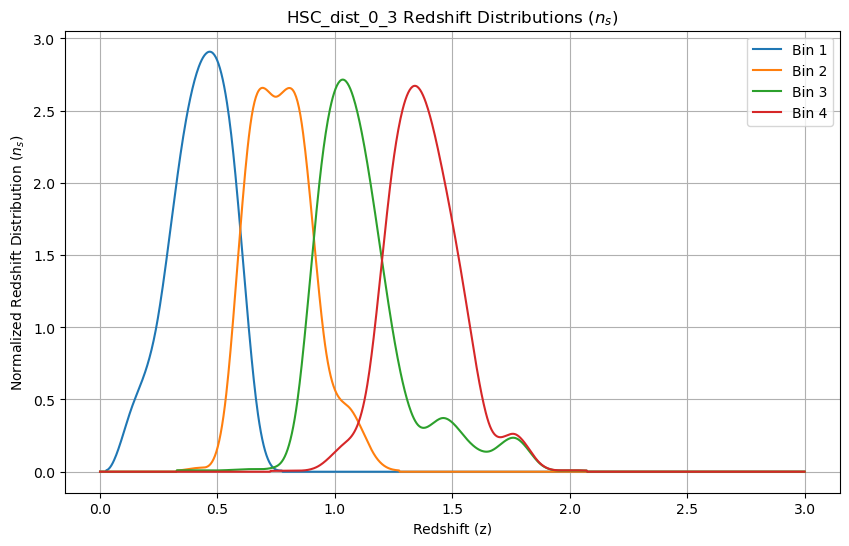

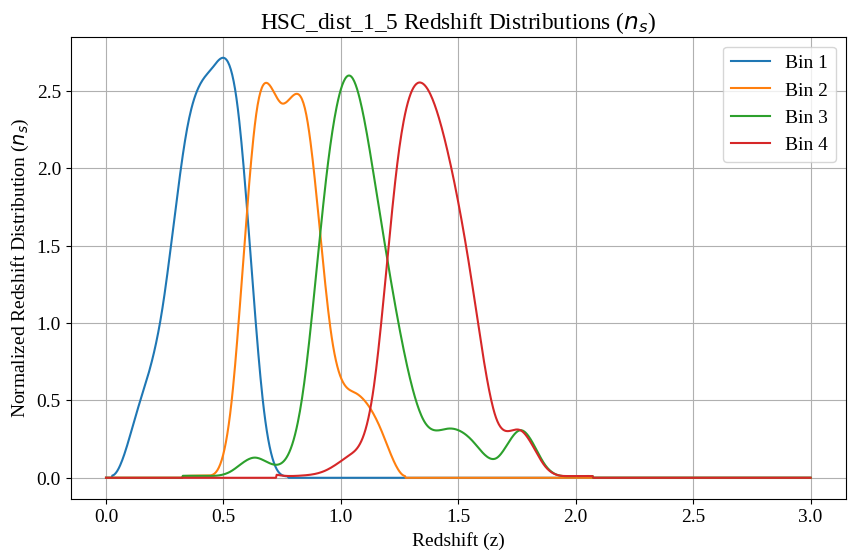

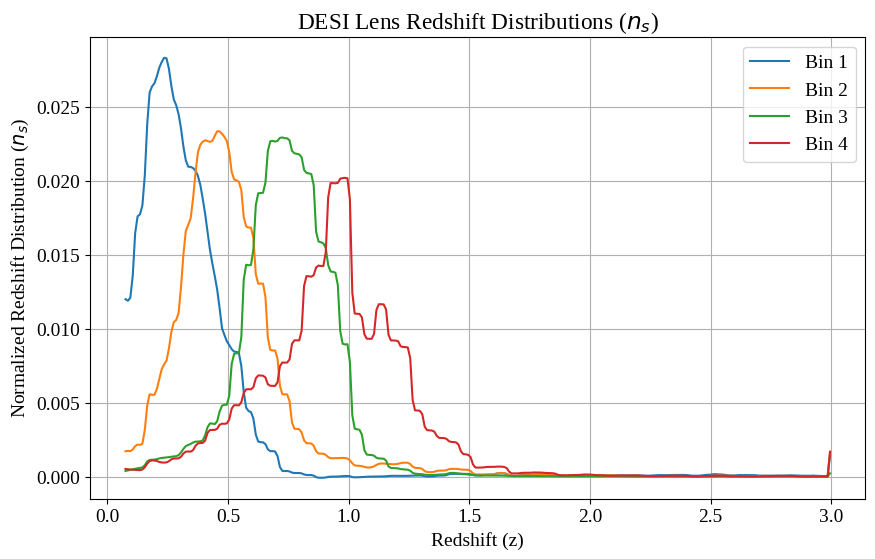

In [7]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [8]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
N_TT = SO_noise_data[:, 1]
N_TE = SO_noise_data[:, 2]
N_EE = SO_noise_data[:, 3]
ells_for_noise_interp = np.arange(2, 5000 + 2) # Assuming n_ell = 5000 for new analysis
medium_ells_for_noise_interp = np.arange(2, 3000 + 2)
low_ells_for_noise_interp = np.arange(2, 1500 + 2)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)
interpolated_N_TT_func = interp1d(S_noise_ells, N_TT, bounds_error=False, fill_value=(N_TT[0], N_TT[-1]))
SO_cmb_noise_TT = interpolated_N_TT_func(ells_for_noise_interp)
interpolated_N_TE_func = interp1d(S_noise_ells, N_TE, bounds_error=False, fill_value=(N_TE[0], N_TE[-1]))
SO_cmb_noise_TE = interpolated_N_TE_func(ells_for_noise_interp)
interpolated_N_EE_func = interp1d(S_noise_ells, N_EE, bounds_error=False, fill_value=(N_EE[0], N_EE[-1]))
SO_cmb_noise_EE = interpolated_N_EE_func(ells_for_noise_interp)

# medium_l_noise
medium_l_SO_cmb_noise_kk = interpolated_N_kk_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_TT = interpolated_N_TT_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_TE = interpolated_N_TE_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_EE = interpolated_N_EE_func(medium_ells_for_noise_interp)

# Handle potential negative noise if for some reason the source data contains them, set to a small positive number
#SO_cmb_noise_kk[SO_cmb_noise_kk < 0] = 1e-30 # Or whatever appropriate small value
#medium_l_SO_cmb_noise_kk[medium_l_SO_cmb_noise_kk < 0] = 1e-30

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_cmb_noise_kk.npy", SO_cmb_noise_kk)
print("Saved SO_cmb_noise_kk to data/SO_cmb_noise_kk.npy")
np.save("data/SO_cmb_noise_TT.npy", SO_cmb_noise_TT)
print("Saved SO_cmb_noise_TT to data/SO_cmb_noise_TT.npy")
np.save("data/SO_cmb_noise_TE.npy", SO_cmb_noise_TE)
print("Saved SO_cmb_noise_TE to data/SO_cmb_noise_TE.npy")
np.save("data/SO_cmb_noise_EE.npy", SO_cmb_noise_EE)
print("Saved SO_cmb_noise_EE to data/SO_cmb_noise_EE.npy")

# save medium l
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/medium_l_SO_cmb_noise_kk.npy", medium_l_SO_cmb_noise_kk)
print("Saved medium_l_SO_cmb_noise_kk to data/medium_l_SO_cmb_noise_kk.npy")
np.save("data/medium_l_SO_cmb_noise_TT.npy", medium_l_SO_cmb_noise_TT)
print("Saved medium_l_SO_cmb_noise_TT to data/medium_l_SO_cmb_noise_TT.npy")
np.save("data/medium_l_SO_cmb_noise_TE.npy", medium_l_SO_cmb_noise_TE)
print("Saved medium_l_SO_cmb_noise_TE to data/medium_l_SO_cmb_noise_TE.npy")
np.save("data/medium_l_SO_cmb_noise_EE.npy", medium_l_SO_cmb_noise_EE)
print("Saved medium_l_SO_cmb_noise_EE to data/medium_l_SO_cmb_noise_EE.npy")

Saved SO_cmb_noise_kk to data/SO_cmb_noise_kk.npy
Saved SO_cmb_noise_TT to data/SO_cmb_noise_TT.npy
Saved SO_cmb_noise_TE to data/SO_cmb_noise_TE.npy
Saved SO_cmb_noise_EE to data/SO_cmb_noise_EE.npy
Saved medium_l_SO_cmb_noise_kk to data/medium_l_SO_cmb_noise_kk.npy
Saved medium_l_SO_cmb_noise_TT to data/medium_l_SO_cmb_noise_TT.npy
Saved medium_l_SO_cmb_noise_TE to data/medium_l_SO_cmb_noise_TE.npy
Saved medium_l_SO_cmb_noise_EE to data/medium_l_SO_cmb_noise_EE.npy


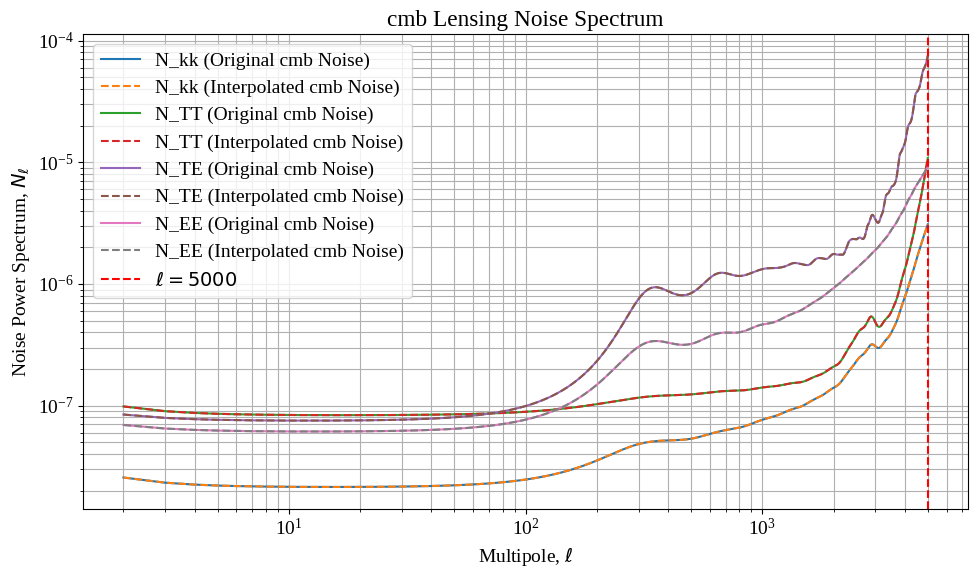

In [9]:
# plot cmb noise to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_TT, label='N_TT (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_TT, label='N_TT (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_TE, label='N_TE (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_TE, label='N_TE (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_EE, label='N_EE (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_EE, label='N_EE (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}$')
plt.title('cmb Lensing Noise Spectrum')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [10]:
# make and save shot and shape noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_cmb_noise_kk was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_cmb_noise_kk was already saved

# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)
print("SO_cmb_noise_kk:", SO_cmb_noise_kk)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]
SO_cmb_noise_kk: [2.566829e-08 2.327497e-08 2.244052e-08 ... 3.084815e-06 3.088479e-06
 3.088479e-06]


In [11]:
# 1. Save Full DESI Lens Data (all 4 bins: columns z, nz_a, nz_b, nz_c, nz_d)
# Note: DESI_lens_data was already column-stacked in Cell 4
np.save("data/DESI_lens_data.npy", DESI_lens_data)

# 2. Save Full HSC Source Data (all 4 bins for both redshift ranges)
np.save("data/HSC_dist_0_3.npy", HSC_dist_0_3)
np.save("data/HSC_dist_1_5.npy", HSC_dist_1_5)

# 3. Save Full DESI Shot Noise and Shape Noise (Arrays for all 4 bins)
# These were calculated for all bins using DESI_n_bar_steradian in Cell 8
np.save("data/DESI_shot_noise.npy", DESI_shot_noise)
np.save("data/DESI_shape_noise.npy", DESI_shape_noise)

# Verification Printouts
print("Full datasets saved successfully!")
print("DESI Lens Data shape: ", DESI_lens_data.shape)
print("HSC 0.3-3 Dist shape: ", HSC_dist_0_3.shape)
print("DESI Shot Noise array:", DESI_shot_noise)
print("DESI Shape Noise array:", DESI_shape_noise)

Full datasets saved successfully!
DESI Lens Data shape:  (293, 5)
HSC 0.3-3 Dist shape:  (1000, 5)
DESI Shot Noise array: [3.71938241e-06 2.05683606e-06 1.87572303e-06 2.05406217e-06]
DESI Shape Noise array: [2.51430251e-07 1.39042117e-07 1.26798877e-07 1.38854603e-07]


## CCL and CosmoPower

In [12]:
# CCL and CosmoPower
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

CCL cosmology parameters:
Omega_c: the density fraction at z=0 of CDM.
Omega_b: the density fraction at z=0 of baryons.
h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.
Omega_k: the curvature density fraction at 𝑧 =0.
Omega_g: the density of radiation (not including massless neutrinos.
w0: first order term of the dark energy equation of state.
wa: second order term of the dark energy equation of state.


In [13]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3158
Omega_c = 0.265
Omega_b = 0.0508
A_s = 2.1006e-9
n_s = 0.966
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='boltzmann_camb', extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb', extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s = A_s,
                               n_s=n_s, transfer_function='boltzmann_camb', extra_parameters={"camb": {"dark_energy_model": "ppf"}})

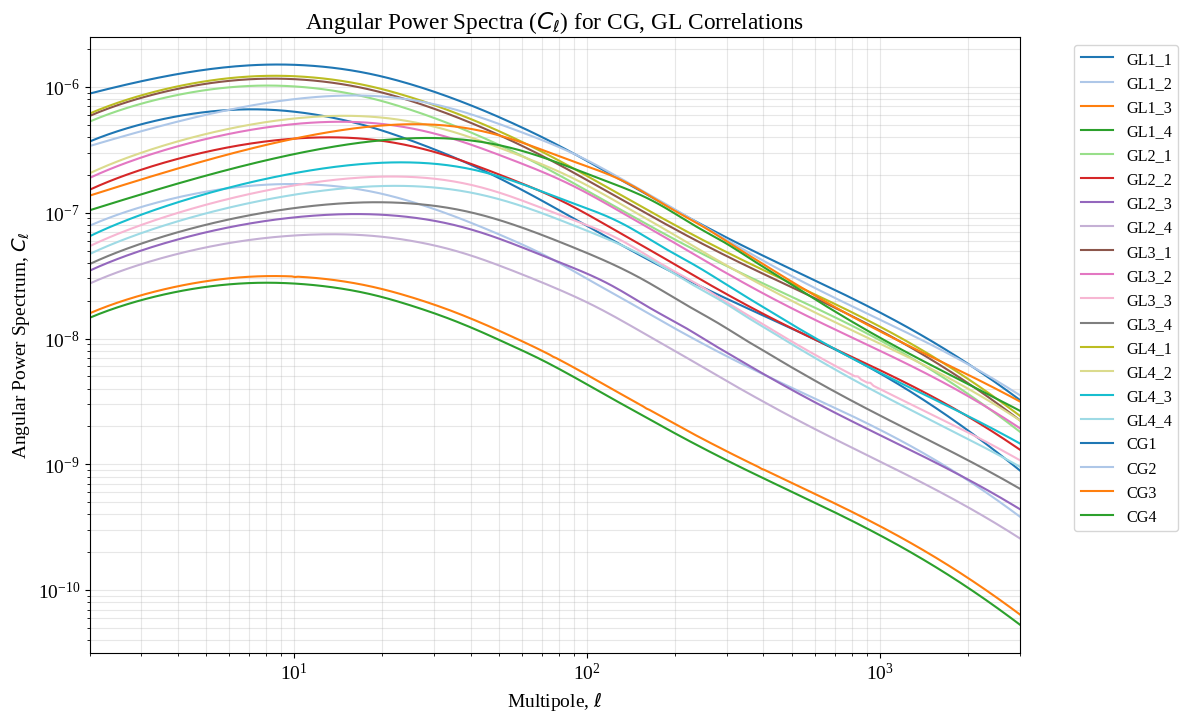

In [14]:
# plot lensing ratio angular power spectra w/o emulator

CG_GL_spectra = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG', 'GL'],
    plot_linear = False)

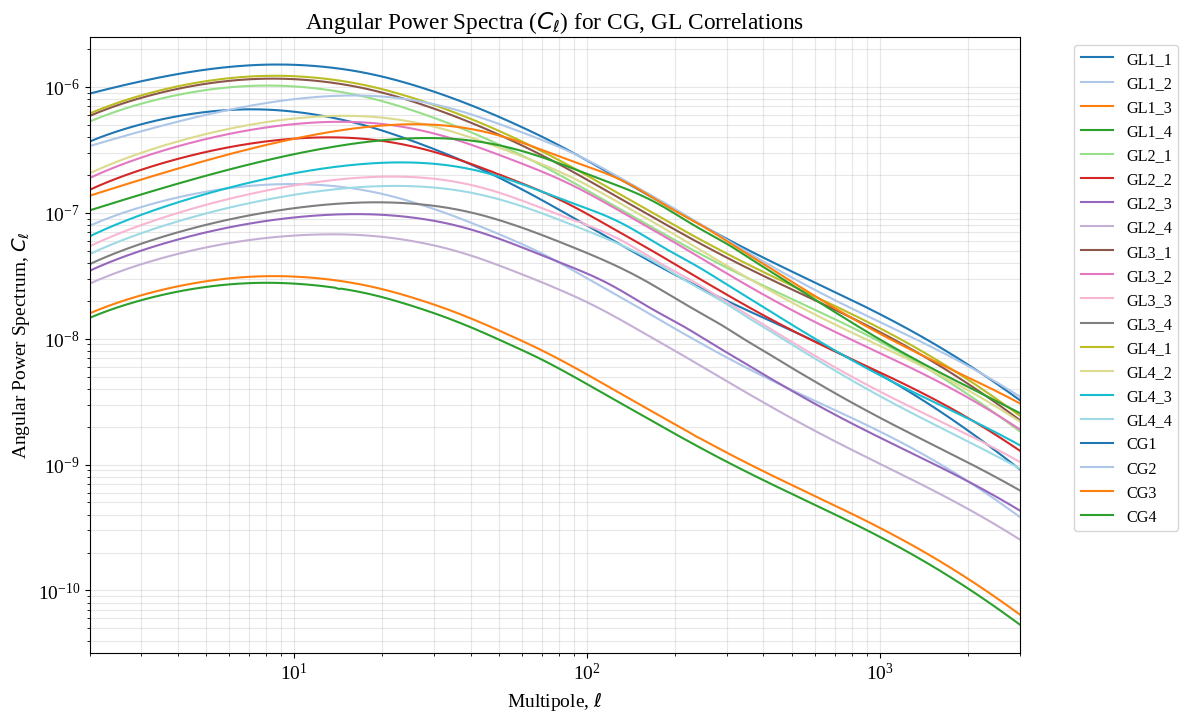

In [15]:
# plot angular power spectra w/ emulator

a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full = make_Pk2D(
    flat_LCDM_cosmology, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)

CG_GL_spectra = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG', 'GL'],
    Pk2D_object = Pk2D_full,
    plot_linear = False
)

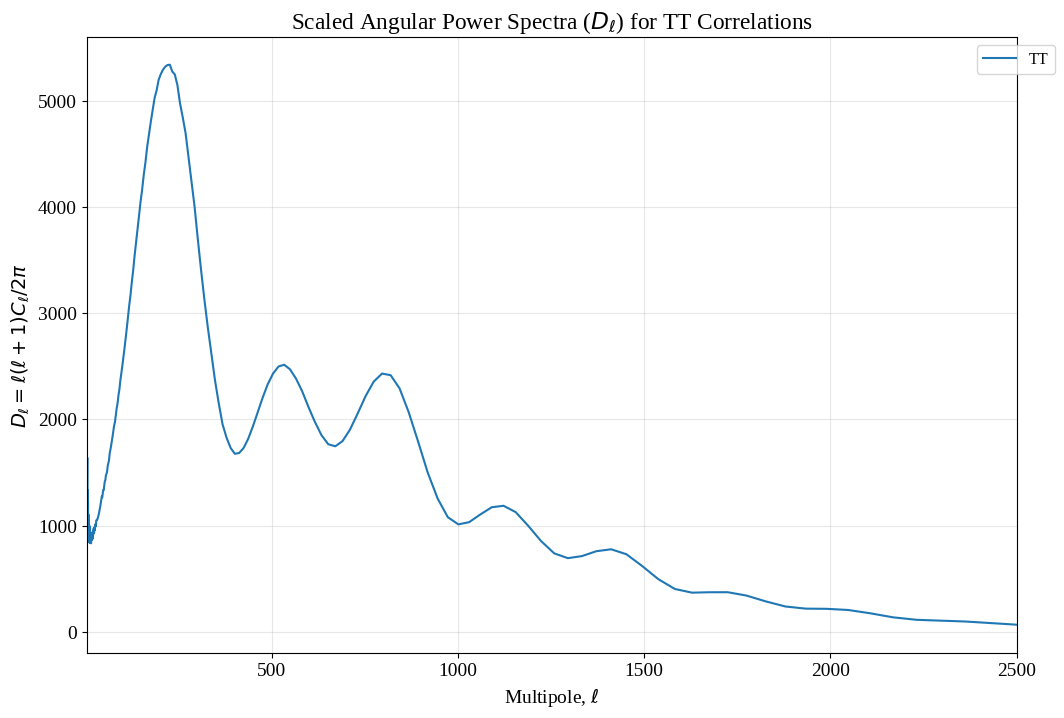

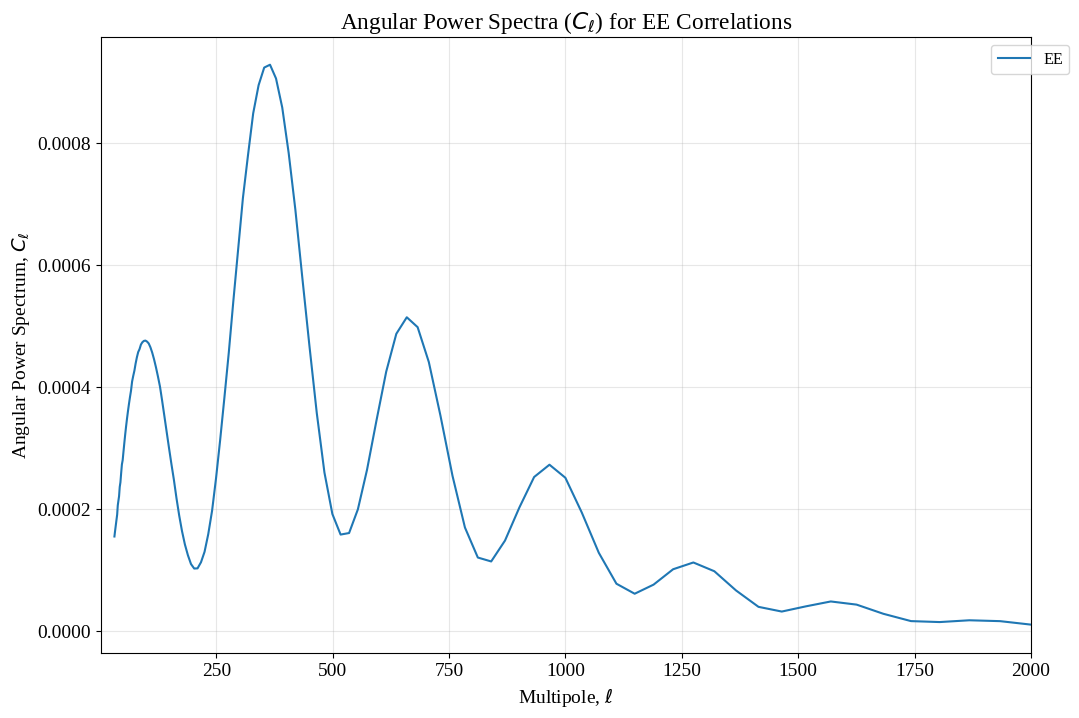

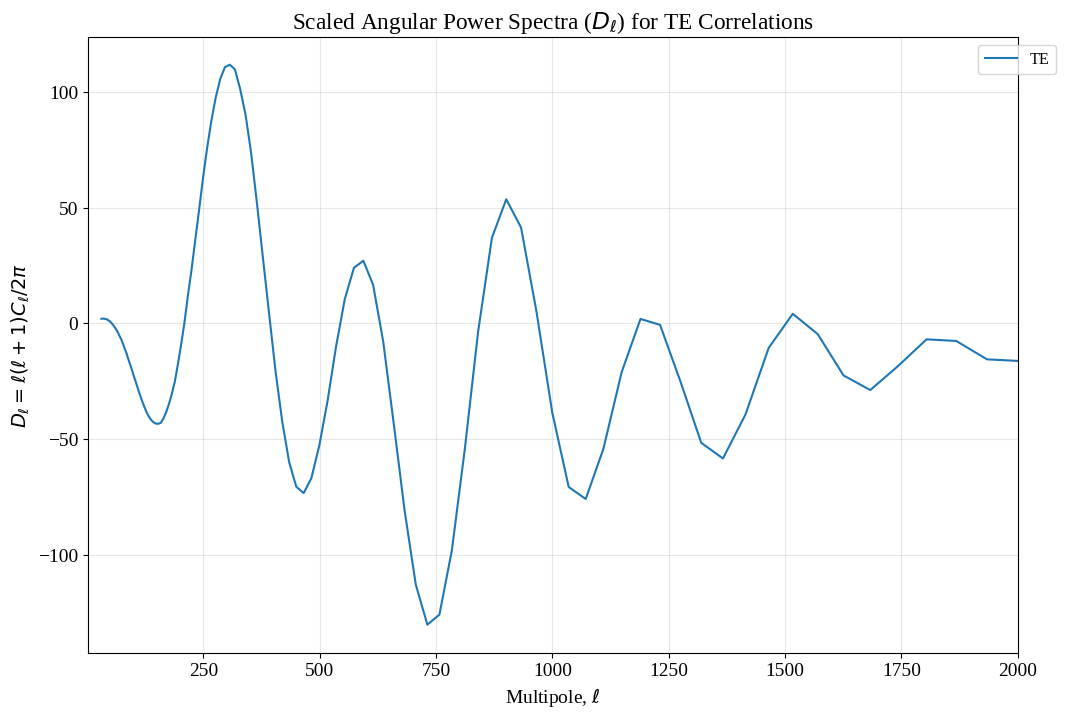

In [16]:
# plot cmb primary spectra
# compare to https://www.kicc.cam.ac.uk/research/cosmic-microwave-background-and-the-early-universe/CMB-cosmological-parameters

TT_spectra = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['TT'],
    l_min = 2,
    n_ell = 2500,
    plot_scaled = True)

EE_spectra = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['EE'],
    l_min = 30,
    n_ell = 2000,
    plot_scaled = False)

TE_spectra = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['TE'],
    l_min = 30,
    n_ell = 2000,
    plot_scaled = True)

## Recreation of Prat Results

In [17]:
# reference: https://arxiv.org/pdf/1810.02212
# sigma_epsilone = 0.26
# For the purposes of these forecasts, we adopt the best-fit ΛCDM cosmological
# model from the analysis ofTT,TE,EE+lowP+lensing+ext datasets in Ade et al. (2016).

# We do LSST + cmb-S4 since that's one of two that is graphed, and I didn't want to deal with separate populations of lens bins

# Source Bins: We assume that LSST is used to measure shapes of source galaxies,
# with a source density of 25 galaxies per sq. arcmin and redshift range from z = 1.0 to z = 1.6.
# Lens Bins:  We assume that the LSST tracer galaxy sample is divided into 10 bins
# between z = 0.2 and z = 0.7, with number density of 100 galaxies per square degree for each bin.
# cmb Lensing: The cmb lensing map is assumed to come from a Stage 4 (cmb-S4) like experiment
# we adopt the minimum variance cmb lensing noise curve from Schaan et al.
# multiplicative shear bias from LSST can be calibrated to σ(m) = 0.001

# Prior: geometrical Planck prior, curved LCDM, sample over omega_k, omega_m, w
#  marginalize over h and Ωb as these appear in the geometrical Planck prior

Saved Prat_lens_data to data/Prat_lens_data.npy
Saved Prat_source_data to data/Prat_source_data.npy


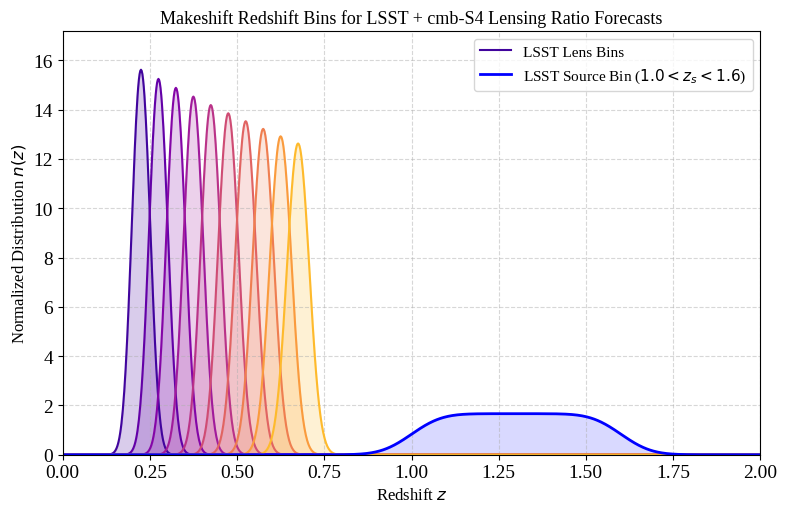

In [18]:
# create lens and source bins to be used for Prat check
# LSST + cmb-S4

# define redshift grid
z = np.linspace(0.0, 2.0, 1000)
dz = z[1] - z[0]

# build the 10 photometric lens bins (0.2 < z < 0.7) with equal number of galaxies
lens_edges = np.linspace(0.2, 0.7, 11)
lens_bins = []

# assume a redMaGiC-like photo-z scatter profile: \sigma_z = 0.0166 * (1 + z)
# "Such densities are comparable to what is currently achieved with DES redMaGiC"
# "the DES Y1 redMaGiC photo-zs have a scatter of σz = 0.0166(1 + z)"
for i in range(10):
    z_min, z_max = lens_edges[i], lens_edges[i+1]
    z_mid = (z_min + z_max) / 2.0

    # initialize nominal window
    top_hat = np.zeros_like(z)
    top_hat[(z >= z_min) & (z <= z_max)] = 1.0

    # Calculate pixel-level Gaussian smoothing representing photo-z scatter
    sigma = 0.0166 * (1 + z_mid)
    sigma_pix = sigma / dz

    # Convolve to get the realistic underlying true n(z) distribution
    nz_lens = gaussian_filter1d(top_hat, sigma_pix)

    # Normalize the distribution
    if np.sum(nz_lens) > 0:
        nz_lens /= np.sum(nz_lens) * dz
    lens_bins.append(nz_lens)

# build the single source bin (1.0 < z < 1.6)
source_min, source_max = 1.0, 1.6
source_mid = (source_min + source_max) / 2.0

top_hat_source = np.zeros_like(z)
top_hat_source[(z >= source_min) & (z <= source_max)] = 1.0

# LSST expected source sample photo-z scatter seems to be ~ \sigma_z = 0.03 * (1 + z)
# https://arxiv.org/pdf/2510.07370
sigma_src = 0.03 * (1 + source_mid)
sigma_src_pix = sigma_src / dz
nz_source = gaussian_filter1d(top_hat_source, sigma_src_pix)
nz_source /= np.sum(nz_source) * dz

# make into arrays
Prat_lens_data = np.column_stack([z] + lens_bins)
Prat_source_data = np.column_stack((z, nz_source))

# save data
np.save("data/Prat_lens_data", Prat_lens_data)
print("Saved Prat_lens_data to data/Prat_lens_data.npy")
np.save("data/Prat_source_data", Prat_source_data)
print("Saved Prat_source_data to data/Prat_source_data.npy")

# plot
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, 10))
z_plot = Prat_lens_data[:, 0]

for i in range(10):
    nz_plot = Prat_lens_data[:, i + 1]
    lbl = 'LSST Lens Bins' if i == 0 else ""
    ax.plot(z_plot, nz_plot, color=colors[i], lw=1.5, label=lbl)
    ax.fill_between(z_plot, nz_plot, color=colors[i], alpha=0.2)

ax.plot(Prat_source_data[:, 0], Prat_source_data[:, 1], color='blue', lw=2, label='LSST Source Bin ($1.0 < z_s < 1.6$)')
ax.fill_between(Prat_source_data[:, 0], Prat_source_data[:, 1], color='blue', alpha=0.15)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Normalized Distribution $n(z)$', fontsize=12)
ax.set_title('Makeshift Redshift Bins for LSST + cmb-S4 Lensing Ratio Forecasts', fontsize=13)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, max(np.max(lens_bins) * 1.1, np.max(nz_source) * 1.1))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

SO cmb Noise Shape: (3000,)
Prat N_kk Shape:   (3000,)


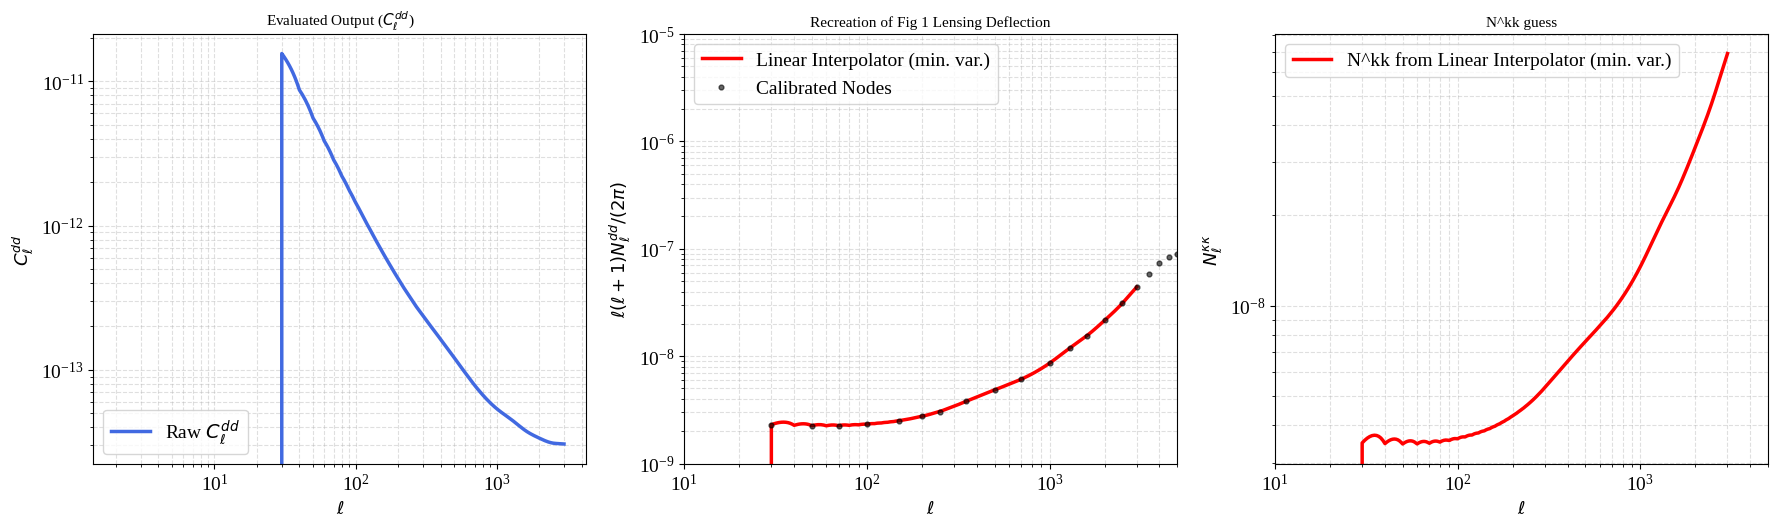

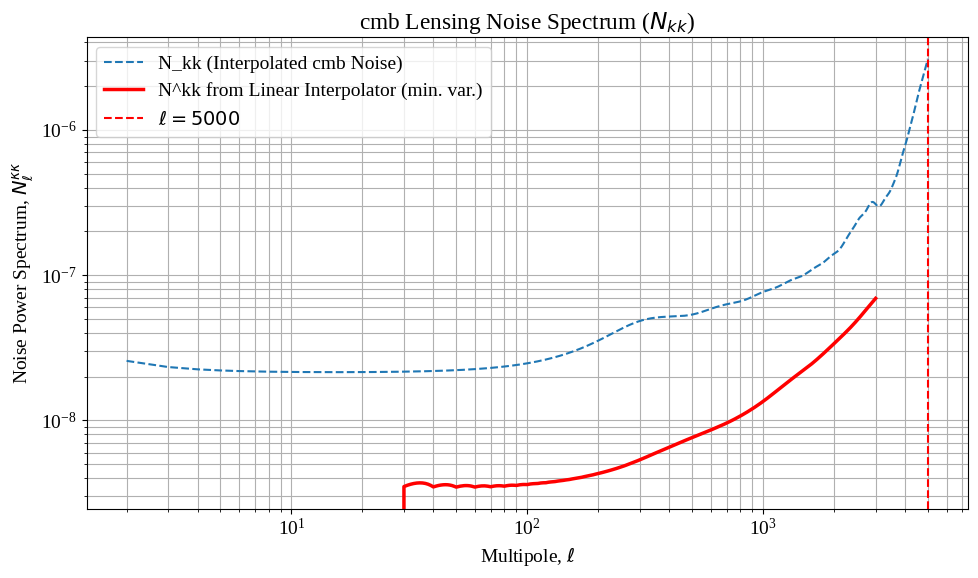

In [19]:
# cmb noise -- estimate from min variance graph, then map from N^dd to N^kk

# 1. High-precision nodes capturing the flat start, the mid-range bump, and the steep end
ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000,
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9, 2.25e-9, 2.25e-9, 2.32e-9,  # l=30 (start) -> shallow dip -> l=100
    2.50e-9, 2.75e-9, 3.05e-9, 3.80e-9,  # Gradual rise (l=200) -> shoulder/bump
    4.85e-9, 6.10e-9, 8.60e-9, 1.20e-8,  # l=500 slows -> l=700 -> l=1000 (<10^-8)
    1.55e-8, 2.15e-8, 3.10e-8, 4.40e-8,  # Steep rise past l=2000 -> l=3000
    5.80e-8, 7.30e-8, 8.40e-8, 9.00e-8   # Upper bounds -> terminates (<10^-7) at l=5000
])

ell_nodes = np.array([
    30, 50, 70, 100, 150, 200, 250, 350, 500, 700, 1000,
    1300, 1600, 2000, 2500, 3000, 3500, 4000, 4500, 5000
])
scaled_nodes = np.array([
    2.30e-9, 2.25e-9, 2.25e-9, 2.32e-9, 2.50e-9, 2.75e-9, 3.05e-9, 
    3.80e-9, 4.85e-9, 6.10e-9, 8.60e-9, 1.20e-8, 1.55e-8, 2.15e-8, 
    3.10e-8, 4.40e-8, 5.80e-8, 7.30e-8, 8.40e-8, 9.00e-8
])

cs_helper = CubicSpline(ell_nodes, scaled_nodes)
ell_base = np.linspace(30, 5000, 500)
scaled_base = cs_helper(ell_base)

# De-scale base values back to raw Cl^pp coordinates:
cl_dd_base = scaled_base * (2 * np.pi) / (ell_base * (ell_base + 1))

cl_dd_linear_interpolator = interp1d(
    ell_base, 
    cl_dd_base, 
    kind='linear', 
    bounds_error=False, 
    fill_value=0.0  # Fills anything outside [30, 5000] with 0
)

# Match your evaluation coordinates exactly to the target array
ell_array = medium_ells_for_noise_interp  

# Evaluate directly in linear space
cl_dd_evaluated = cl_dd_linear_interpolator(ell_array)

# Calculate final physical scaling arrays
scaled_evaluated = ell_array * (ell_array + 1) * cl_dd_evaluated / (2 * np.pi)
Prat_n_kk = ell_array * (ell_array) * cl_dd_evaluated / 4
Prat_cmb_noise = Prat_n_kk

# HARD MASK: Cleanly force any residual values below l=30 to be exactly 0.0
Prat_n_kk[ell_array < 30] = 0.0
scaled_evaluated[ell_array < 30] = 0.0

# Verify the shapes perfectly match now
print("SO cmb Noise Shape:", medium_l_SO_cmb_noise_kk.shape)
print("Prat N_kk Shape:  ", Prat_n_kk.shape)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Left Panel: Pure Evaluated Raw Cl^pp
ax1.loglog(ell_array, cl_dd_evaluated, color='royalblue', lw=2.5, label=r'Raw $C_\ell^{dd}$')
ax1.set_xlabel(r'$\ell$', fontsize=13)
ax1.set_ylabel(r'$C_\ell^{dd}$', fontsize=13)
ax1.set_title(r'Evaluated Output ($C_\ell^{dd}$)', fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')

# Middle Panel: Exact Mirror of Figure 1 Coordinates from arXiv:1607.01761
ax2.loglog(ell_array, scaled_evaluated, color='red', lw=2.5, label='Linear Interpolator (min. var.)')
ax2.scatter(ell_nodes, scaled_nodes, color='black', s=12, zorder=3, alpha=0.6, label='Calibrated Nodes')
ax2.set_xlim(10, 5000)
ax2.set_ylim(1e-9, 1e-5)
ax2.set_xlabel(r'$\ell$', fontsize=13)
ax2.set_ylabel(r'$\ell(\ell + 1) N_\ell^{dd} / (2\pi)$', fontsize=13)
ax2.set_title('Recreation of Fig 1 Lensing Deflection', fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)
ax2.legend(loc='upper left')

# Right Panel: N^kk_l
ax3.loglog(ell_array, Prat_n_kk, color='red', lw=2.5, label='N^kk from Linear Interpolator (min. var.)')
ax3.set_xlim(10, 5000)
ax3.set_xlabel(r'$\ell$', fontsize=13)
ax3.set_ylabel(r'$N_\ell^{\kappa\kappa}$', fontsize=13)
ax3.set_title('N^kk guess', fontsize=11)
ax3.grid(True, which='both', linestyle='--', alpha=0.4)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

# plot to compare min variance and SO noise
plt.figure(figsize=(10, 6))
plt.loglog(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.loglog(medium_ells_for_noise_interp, Prat_n_kk, color='red', lw=2.5, label='N^kk from Linear Interpolator (min. var.)')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}^{\kappa\kappa}$')
plt.title('cmb Lensing Noise Spectrum ($N_{kk}$)')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') 
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [20]:
# noise
sigma = 0.26
Prat_n_bar_deg2 = np.array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100]) # Galaxies per square degree

# convert n_bar from per deg^2 to per steradian
Prat_n_bar_steradian = Prat_n_bar_deg2 * (180.0 / np.pi)**2

# Lens noise: 10 elements for 10 lens bins
Prat_shot_noise = 1.0 / Prat_n_bar_steradian

# Source noise: NumPy array with exactly 1 element for your single source bin
# (Using the first element of your conversion array as the baseline)
Prat_shape_noise = np.array([(sigma ** 2) / Prat_n_bar_steradian[0]])

Prat_shot_noise_elevated = (10 ** 3) * Prat_shot_noise
Prat_shape_noise_elevated = (10 ** 3) * Prat_shape_noise
Prat_cmb_noise_elevated = (10 ** 3) * Prat_cmb_noise
medium_l_SO_cmb_noise_TT_elevated = (10 ** 10) * medium_l_SO_cmb_noise_TT
medium_l_SO_cmb_noise_TE_elevated = (10 ** 10) * medium_l_SO_cmb_noise_TE
medium_l_SO_cmb_noise_EE_elevated = (10 ** 10) * medium_l_SO_cmb_noise_EE

# save
np.save("data/Prat_shot_noise.npy", Prat_shot_noise)
np.save("data/Prat_shape_noise.npy", Prat_shape_noise)

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.309\pm 0.030$ | $\Omega_m = 0.309^{+0.061}_{-0.057}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.032$ | $\Omega_m = 0.307 \pm 0.065$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.000\pm 0.041$ | $\Omega_k = 0.000^{+0.080}_{-0.081}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.041$ | $\Omega_k = 0.000 \pm 0.083$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.97^{+0.47}_{-0.52}$ | $w_0 = -0.97^{+0.89}_{-0.93}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.519$ | $w_0 = -1.000 \pm 1.038$ |
| --- | --- | --- | --- |

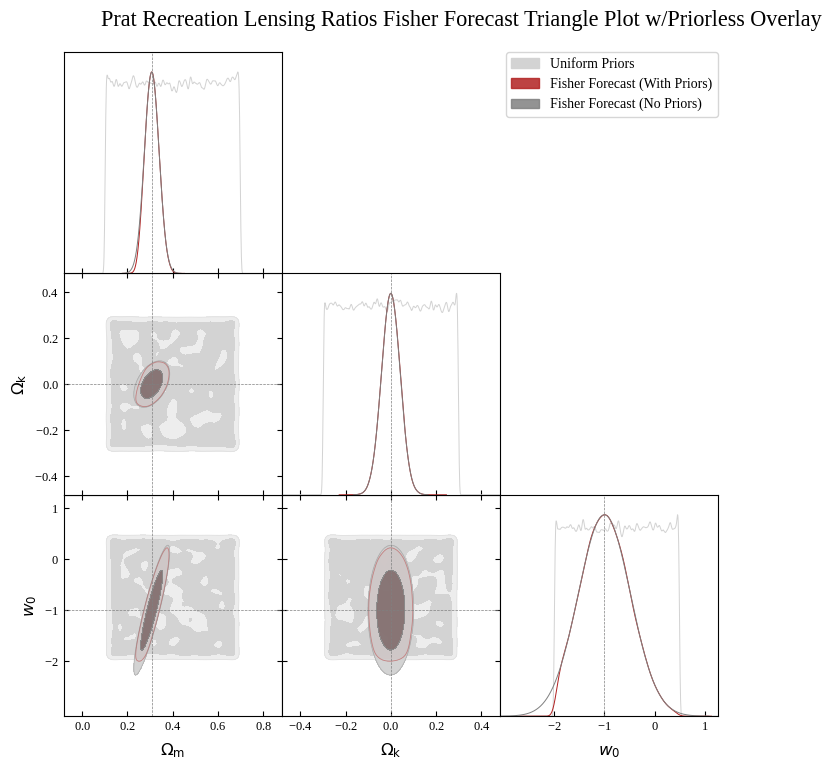

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot.pdf


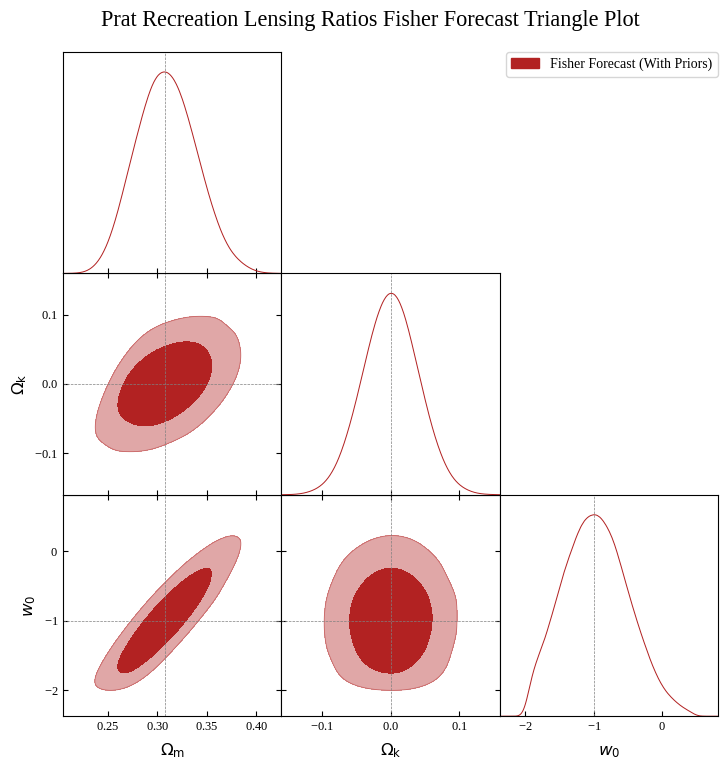

In [22]:
# Fisher forecast w/o primaries

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)
Prat_lensing_ratios_only_spectra_dict = forecaster_c1.spectra_dict

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

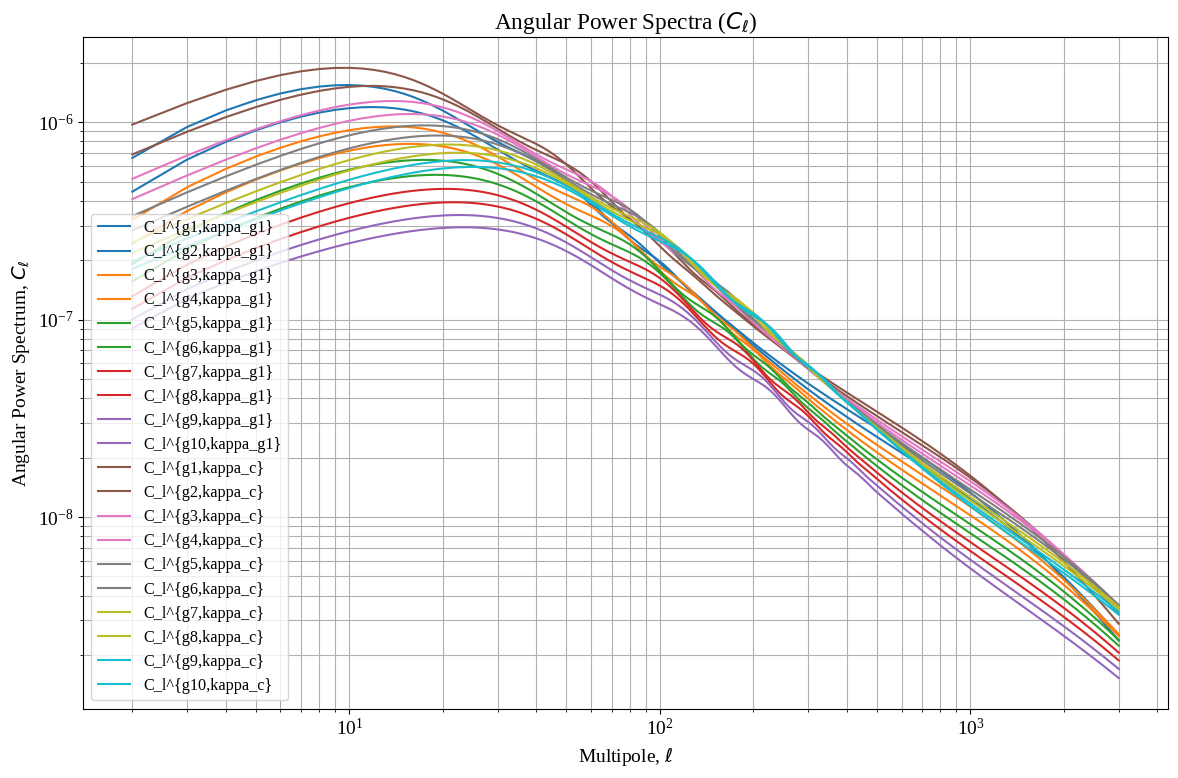

In [22]:
# plot spectra 
plot_spectra_from_dict(Prat_lensing_ratios_only_spectra_dict, title_prefix='Prat LR Angular Power Spectrum', desired_spectra=['CG', 'GL'], plot_scaled=False, plot_linear=False, num_lens_bins=10, num_source_bins=1)

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0069$ | $\Omega_m = 0.307^{+0.014}_{-0.014}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0069$ | $\Omega_m = 0.307 \pm 0.014$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0091$ | $\Omega_k = 0.000^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0091$ | $\Omega_k = 0.000 \pm 0.018$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.00\pm 0.12$ | $w_0 = -1.00^{+0.24}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.124$ | $w_0 = -1.000 \pm 0.248$ |
| --- | --- | --- | --- |

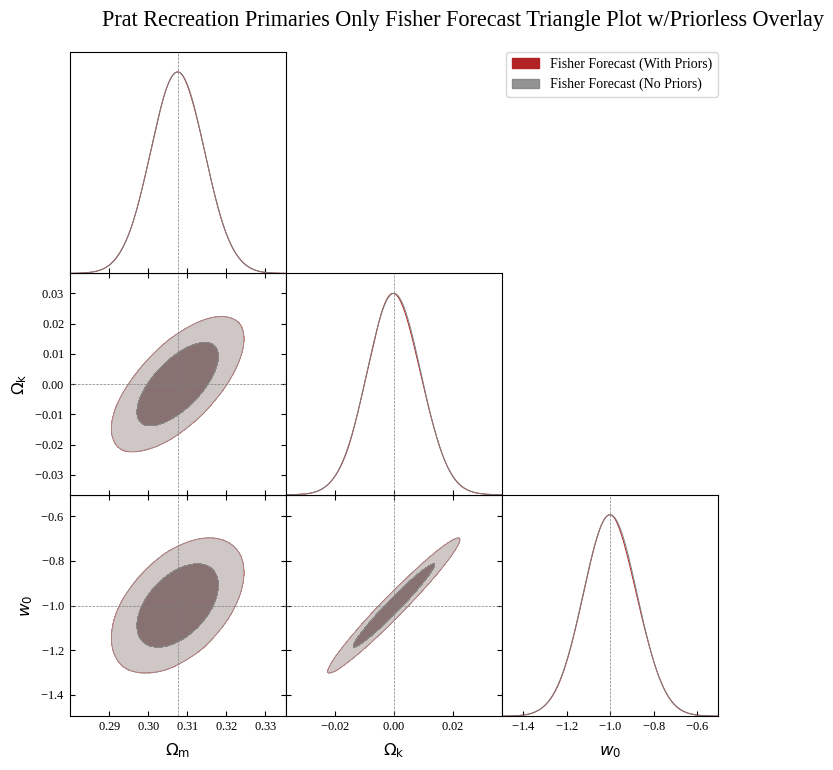

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot.pdf


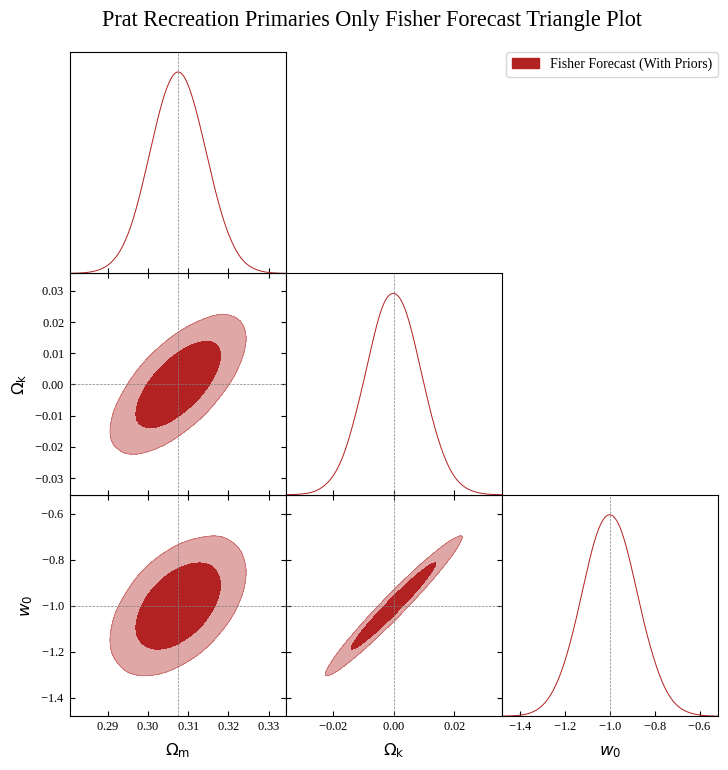

In [23]:
# Fisher forecast w/primaries ONLY 

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)
Prat_primaries_only_spectra_dict = forecaster_c1.spectra_dict

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

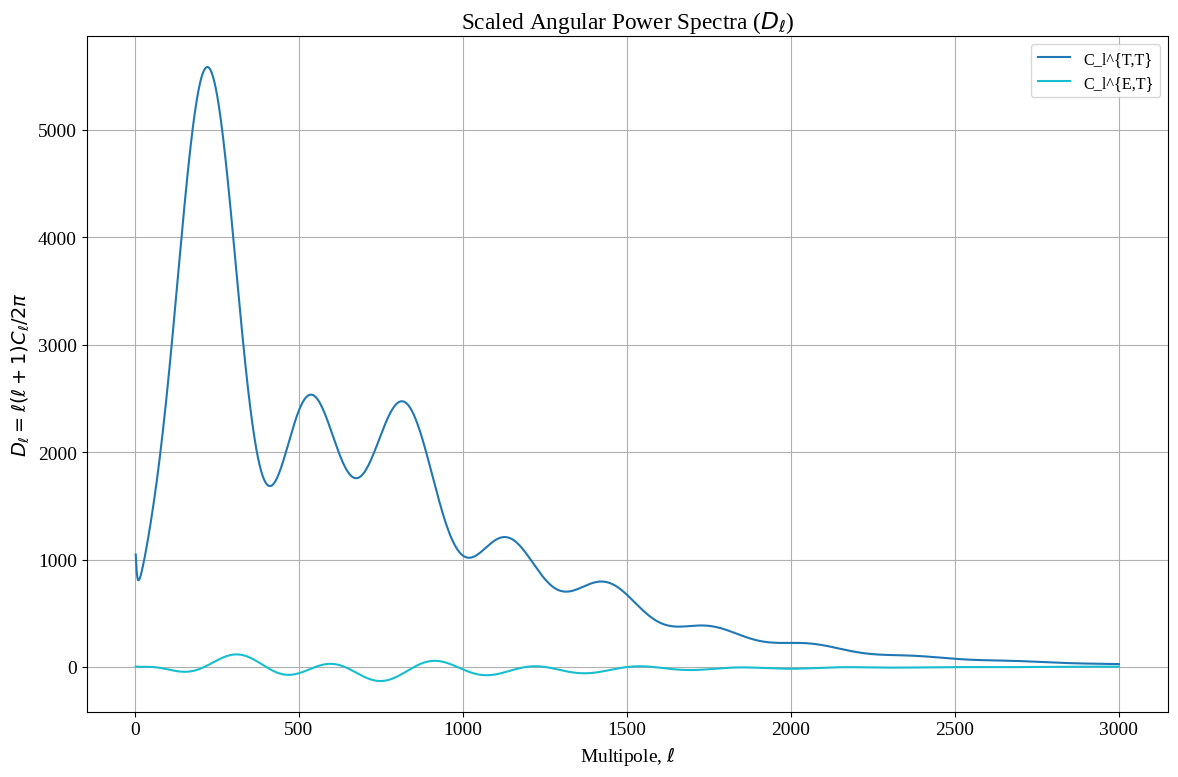

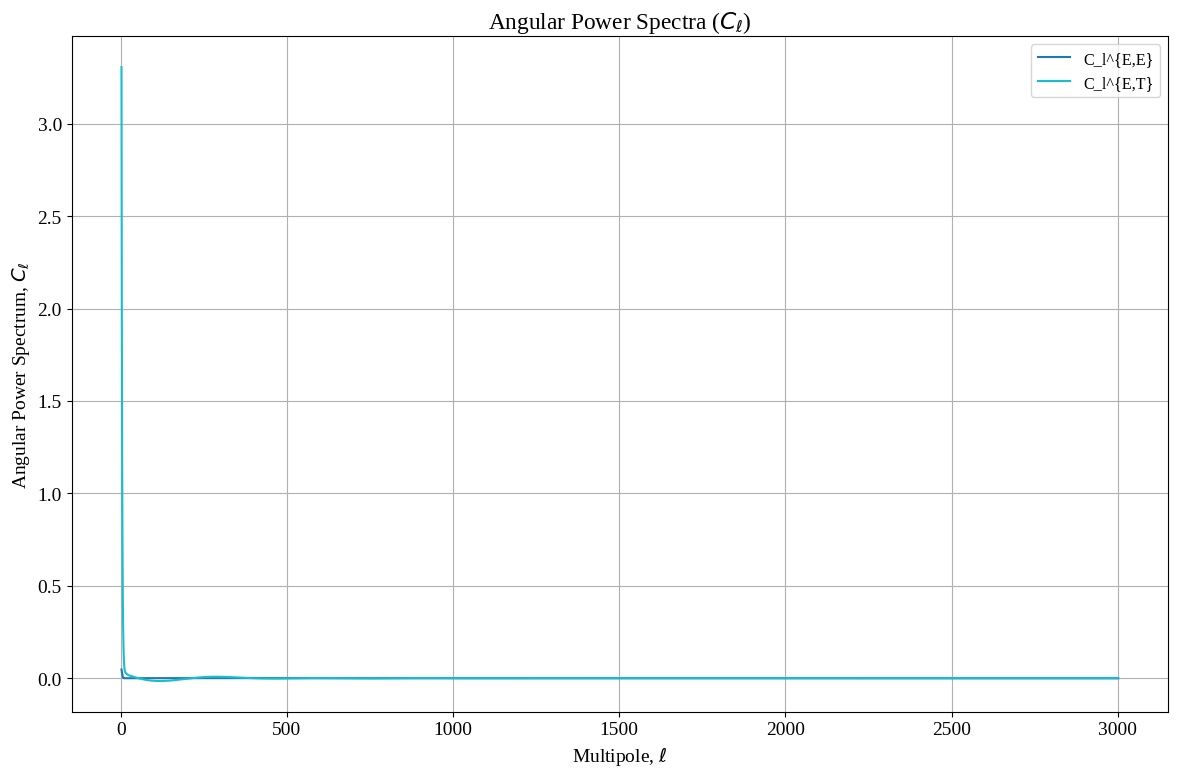

In [25]:
# plot spectra 
plot_spectra_from_dict(Prat_primaries_only_spectra_dict, title_prefix='Prat Primaries Angular Power Spectrum', desired_spectra=['TT', 'TE'], plot_scaled=True, plot_linear=True,  num_lens_bins=10, num_source_bins=1)
plot_spectra_from_dict(Prat_primaries_only_spectra_dict, title_prefix='Prat Primaries Angular Power Spectrum', desired_spectra=['EE'], plot_scaled=False, plot_linear=True, num_lens_bins=10, num_source_bins=1)

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_and_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0067$ | $\Omega_m = 0.308^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0067$ | $\Omega_m = 0.307 \pm 0.013$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0075$ | $\Omega_k = 0.000^{+0.015}_{-0.015}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0075$ | $\Omega_k = 0.000 \pm 0.015$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.9998\pm 0.088$ | $w_0 = -1.00^{+0.17}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.088$ | $w_0 = -1.000 \pm 0.175$ |
| --- | --- | --- | --- |

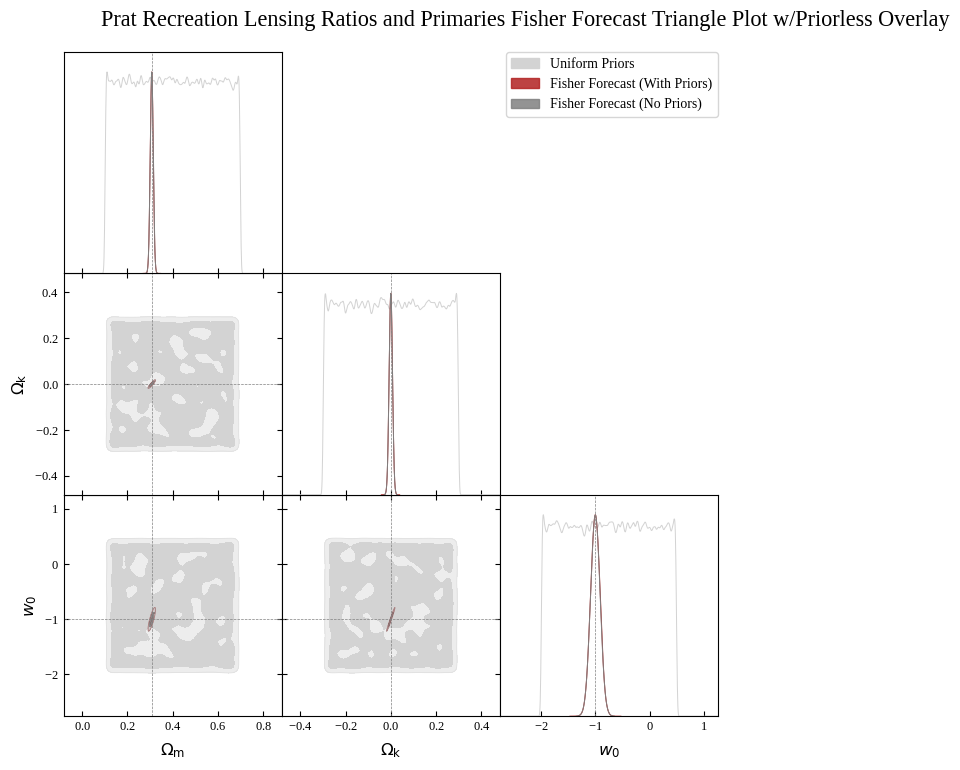

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_and_primaries_fisher_forecast_triangle_plot.pdf


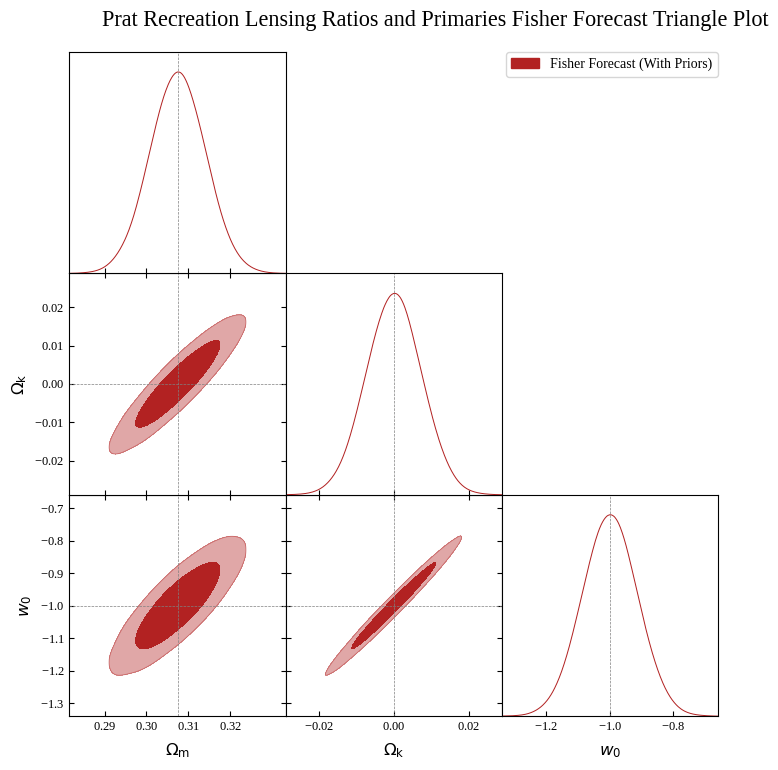

In [26]:
# Fisher forecast w/lensing ratios and primaries

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)
Prat_spectra_dict = forecaster_c1.spectra_dict

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios and Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios and Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

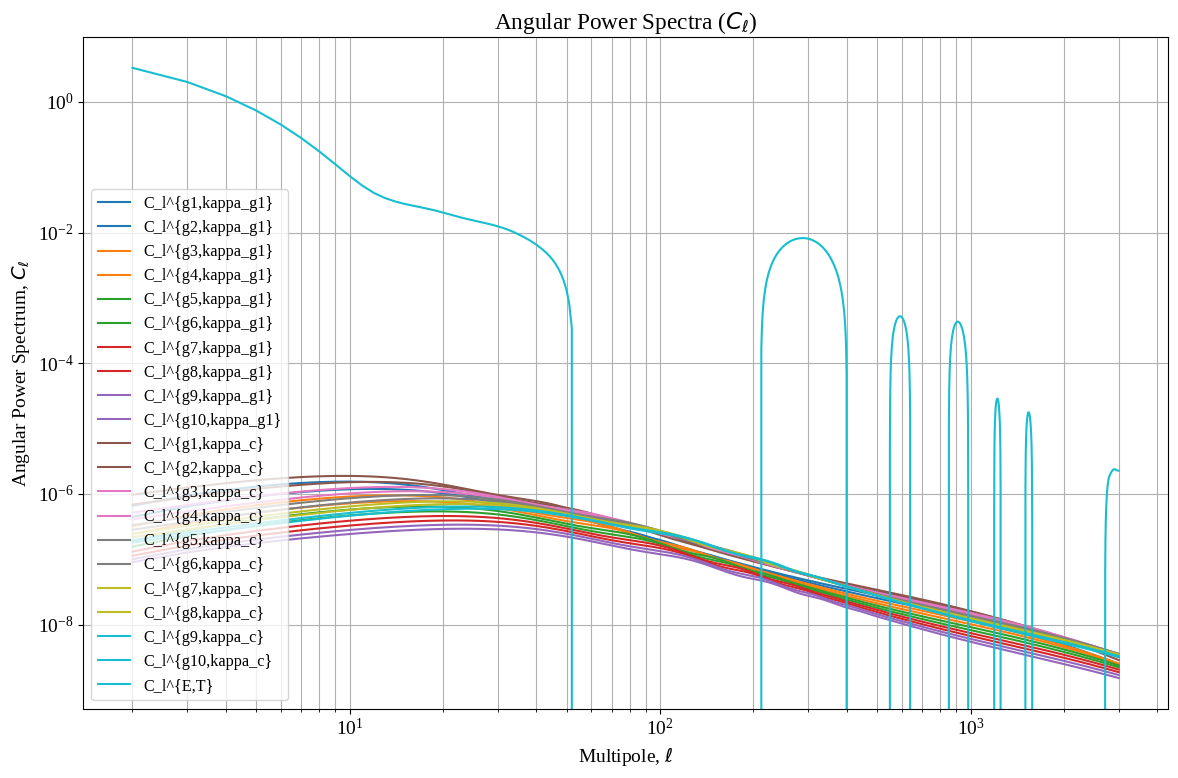

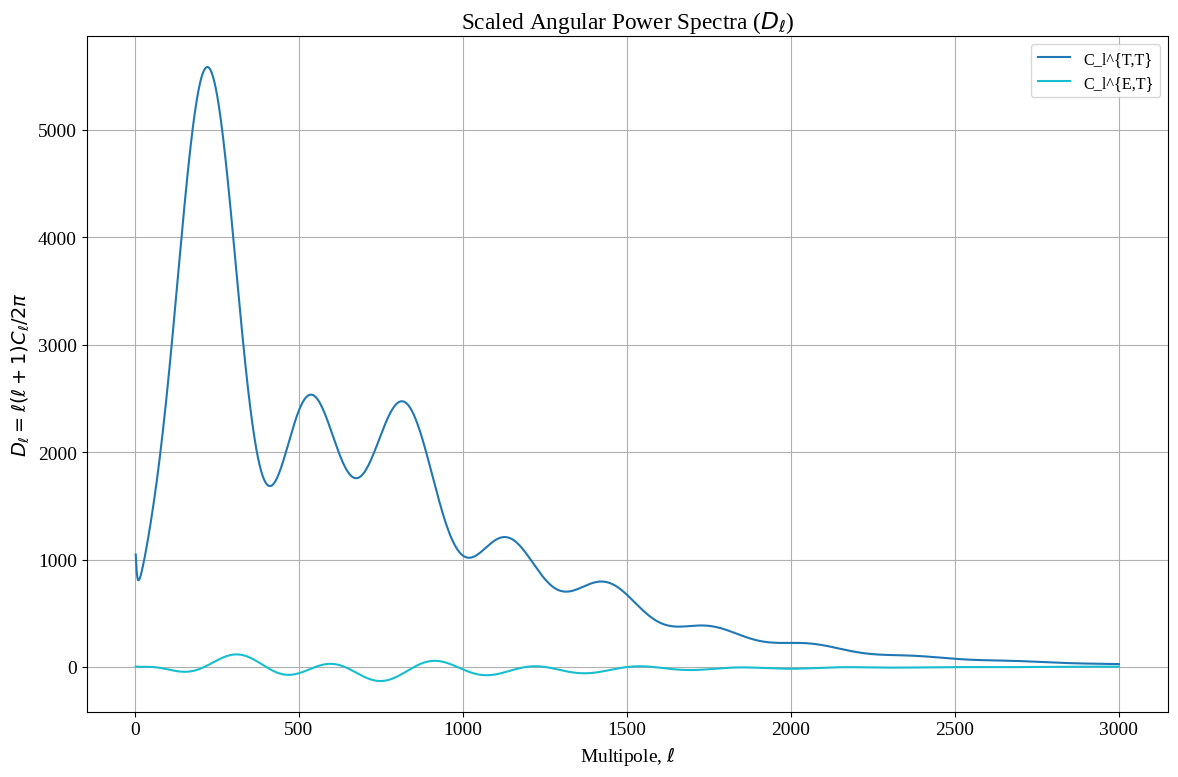

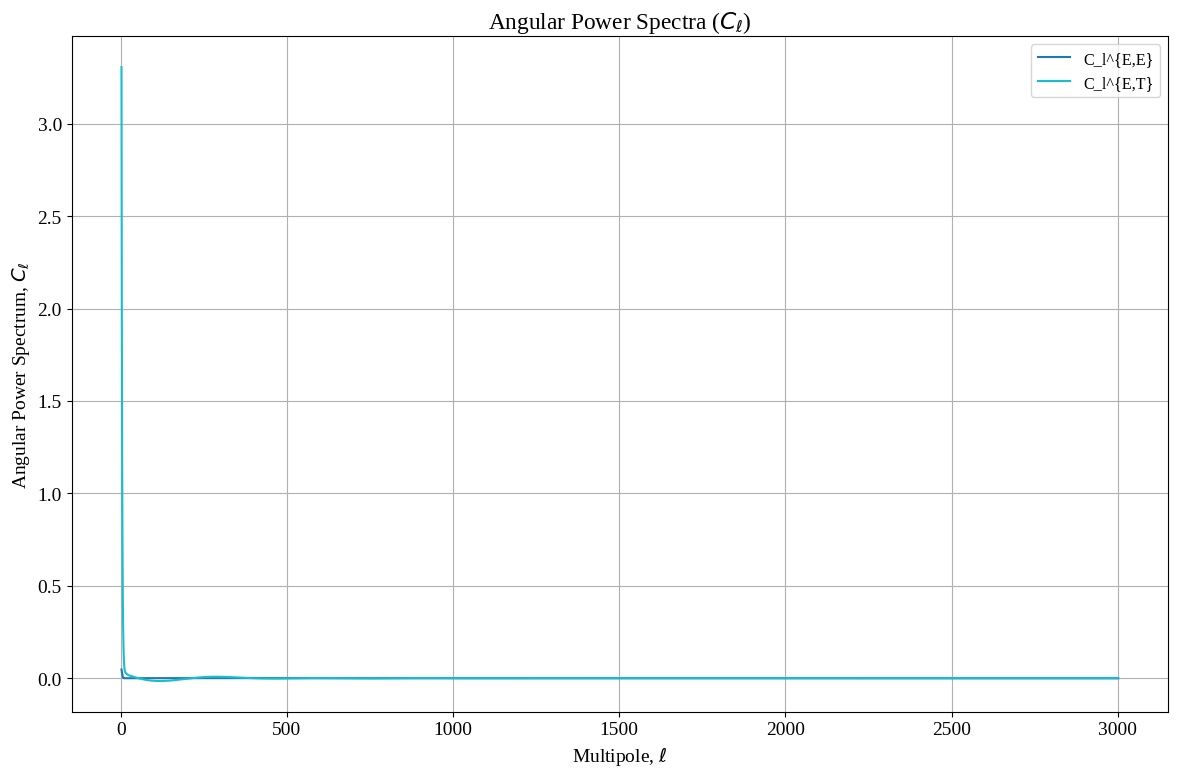

In [27]:
# plot spectra 
plot_spectra_from_dict(Prat_spectra_dict, title_prefix='Prat Angular Power Spectrum', desired_spectra=['GL', 'CG'], plot_scaled=False, plot_linear=False, num_lens_bins=10, num_source_bins=1)
plot_spectra_from_dict(Prat_spectra_dict, title_prefix='Prat Angular Power Spectrum', desired_spectra=['TT', 'TE'], plot_scaled=True, plot_linear=True, num_lens_bins=10, num_source_bins=1)
plot_spectra_from_dict(Prat_spectra_dict, title_prefix='Prat Angular Power Spectrum', desired_spectra=['EE'], plot_scaled=False, plot_linear=True, num_lens_bins=10, num_source_bins=1)

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.350\pm 0.090$ | $\Omega_m = 0.35^{+0.18}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.112$ | $\Omega_m = 0.307 \pm 0.225$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = -0.003\pm 0.049$ | $\Omega_k = -0.003^{+0.096}_{-0.098}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.053$ | $\Omega_k = 0.000 \pm 0.106$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.82\pm 0.54$ | $w_0 = -0.8^{+1.0}_{-1.0}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.662$ | $w_0 = -1.000 \pm 1.324$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.73^{+0.20}_{-0.13}$ | $h = 0.73^{+0.27}_{-0.28}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.289$ | $h = 0.677 \pm 0.577$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.080^{+0.021}_{-0.067}$ | $\Omega_b = 0.080^{+0.085}_{-0.069}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.092$ | $\Omega_b = 0.049 \pm 0.184$ |
| --- | --- | --- | --- |

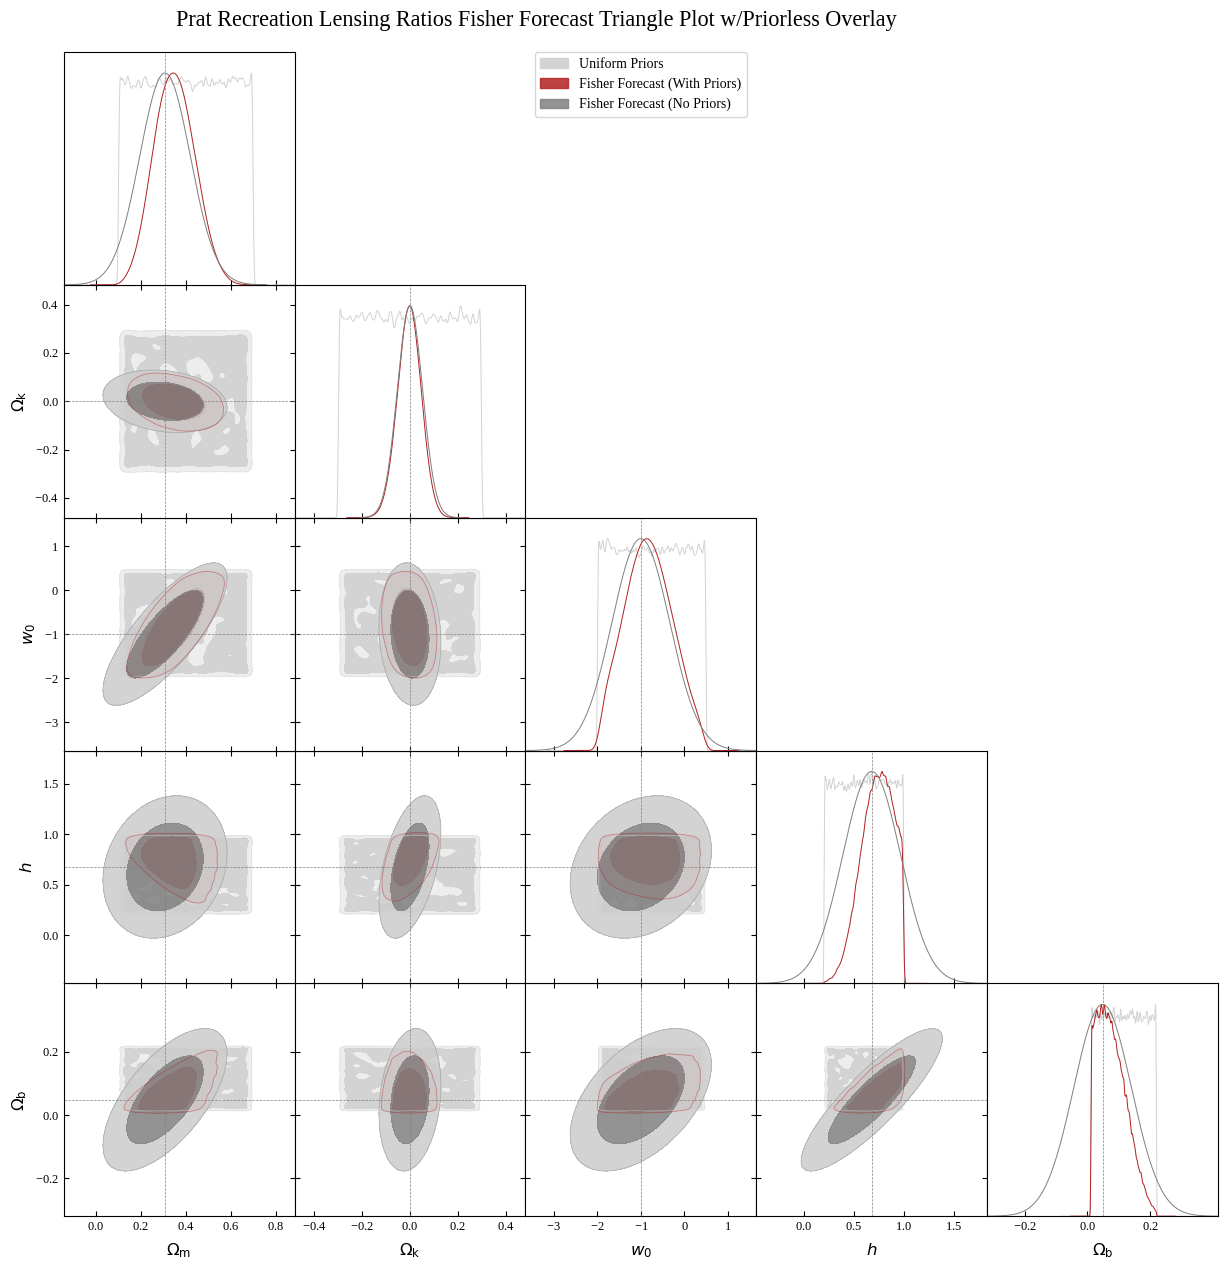

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_fisher_forecast_triangle_plot.pdf


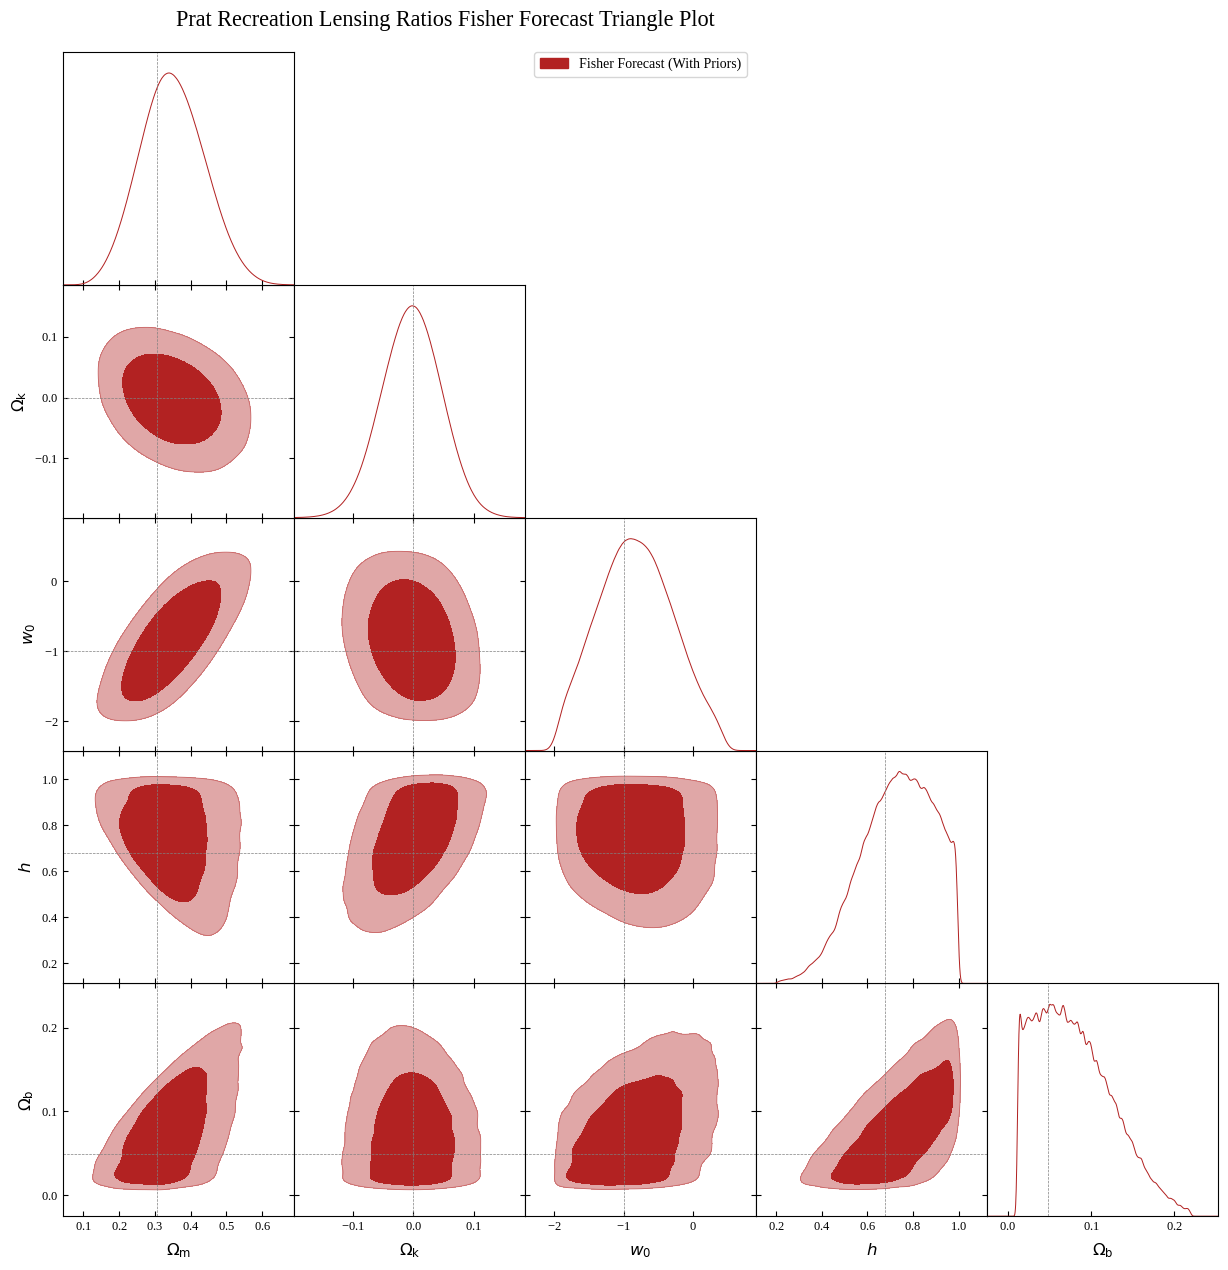

In [23]:
# Fisher forecast w/o primaries w/five params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'h', 'Omega_b']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.35^{+0.11}_{-0.21}$ | $\Omega_m = 0.35^{+0.27}_{-0.25}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.216$ | $\Omega_m = 0.307 \pm 0.432$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = -0.004^{+0.018}_{-0.016}$ | $\Omega_k = -0.004^{+0.030}_{-0.033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.021$ | $\Omega_k = 0.000 \pm 0.043$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.89^{+0.30}_{-0.44}$ | $w_0 = -0.89^{+0.68}_{-0.62}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.501$ | $w_0 = -1.000 \pm 1.002$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.056^{+0.017}_{-0.033}$ | $\Omega_b = 0.056^{+0.044}_{-0.039}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.034$ | $\Omega_b = 0.049 \pm 0.068$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.63^{+0.23}_{-0.12}$ | $h = 0.63^{+0.28}_{-0.30}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.239$ | $h = 0.677 \pm 0.477$ |
| --- | --- | --- | --- |

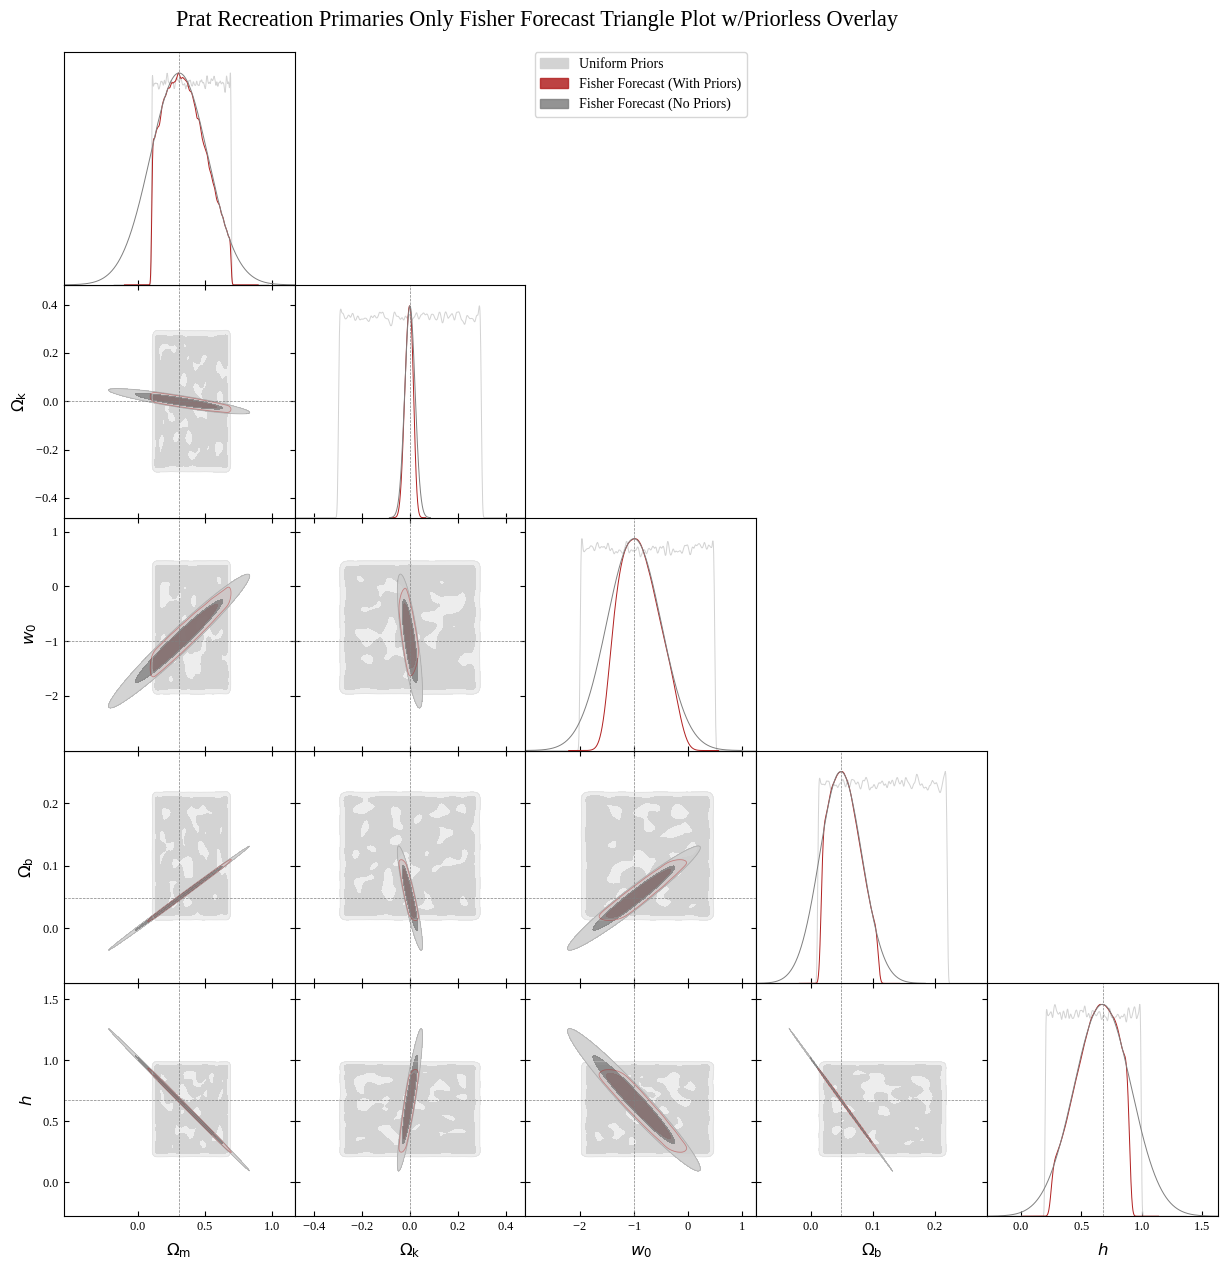

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_primaries_only_fisher_forecast_triangle_plot.pdf


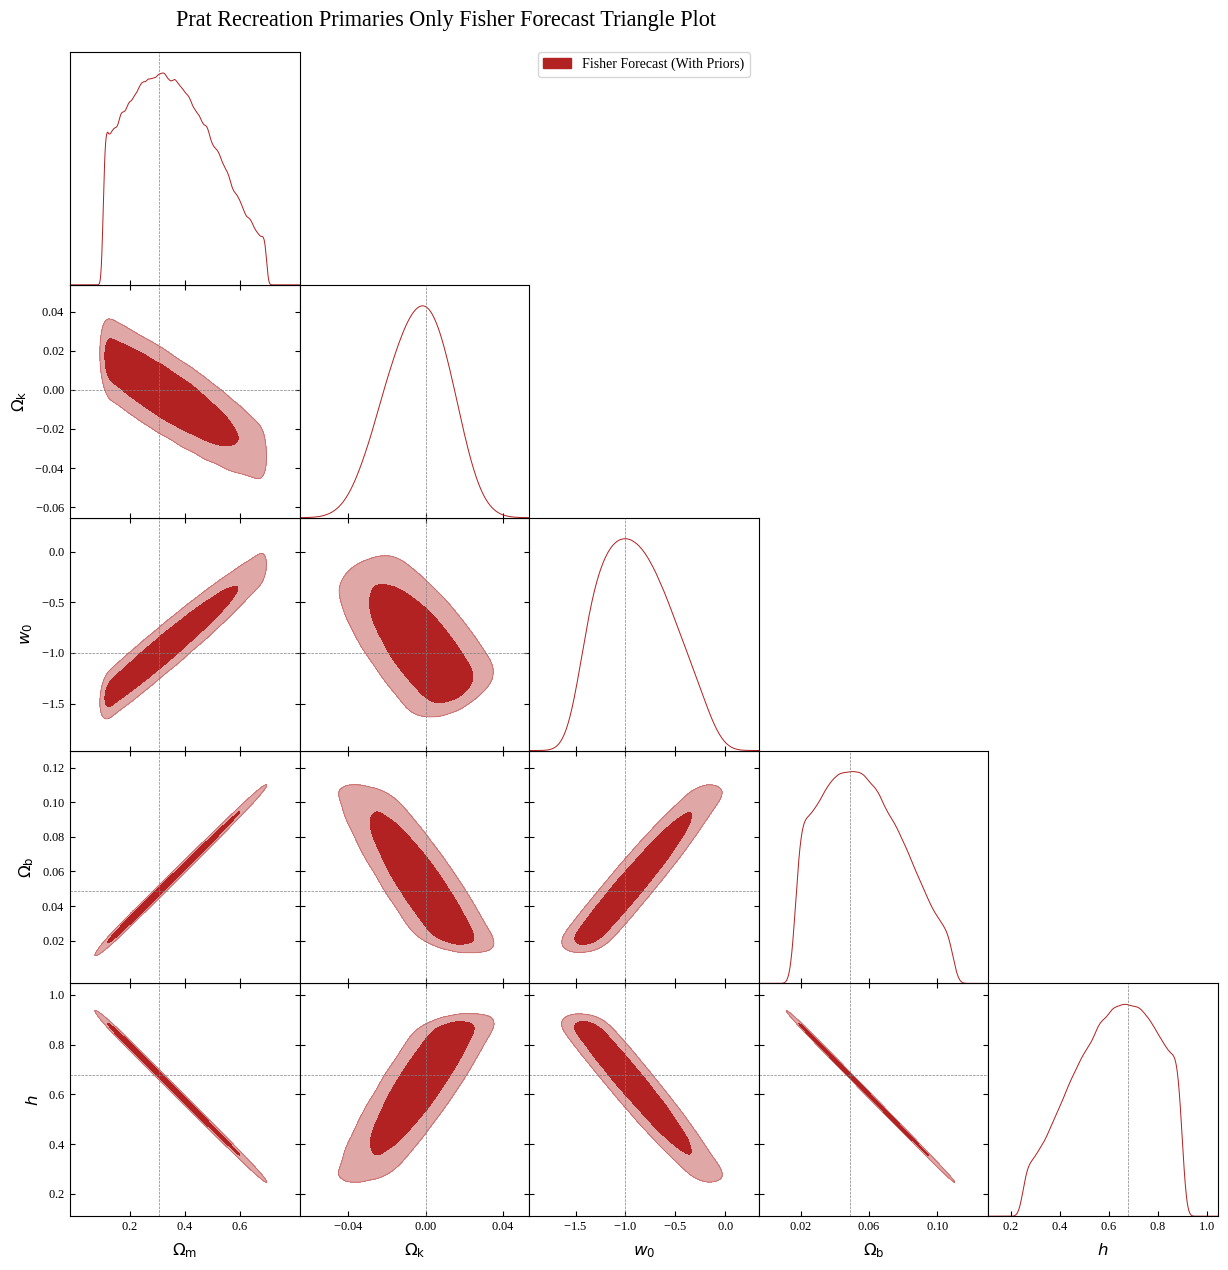

In [29]:
# Fisher forecast w/primaries ONLY (five params)

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Primaries Only Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/pratt_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.308\pm 0.075$ | $\Omega_m = 0.31^{+0.15}_{-0.15}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.076$ | $\Omega_m = 0.307 \pm 0.153$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.000\pm 0.011$ | $\Omega_k = 0.000^{+0.022}_{-0.021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.011$ | $\Omega_k = 0.000 \pm 0.022$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.998\pm 0.20$ | $w_0 = -0.998^{+0.40}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.204$ | $w_0 = -1.000 \pm 0.408$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.049\pm 0.012$ | $\Omega_b = 0.049^{+0.024}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.012$ | $\Omega_b = 0.049 \pm 0.024$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.677\pm 0.084$ | $h = 0.68^{+0.16}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.085$ | $h = 0.677 \pm 0.170$ |
| --- | --- | --- | --- |

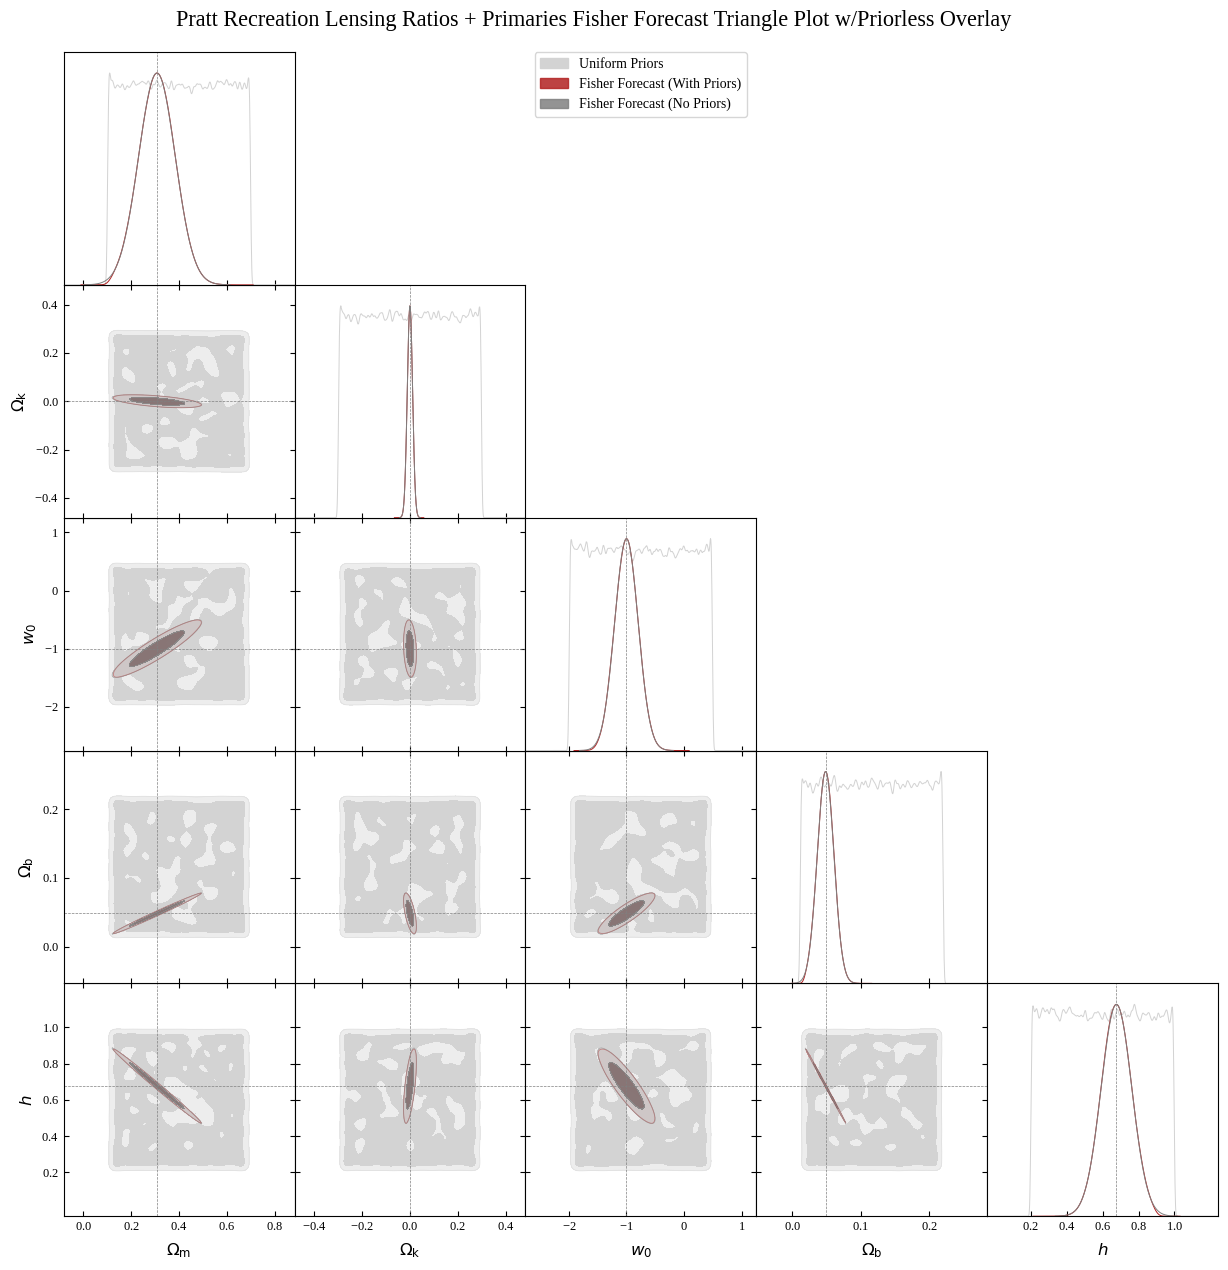

Plot successfully saved to: plots/Fisher Forecasts/pratt_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


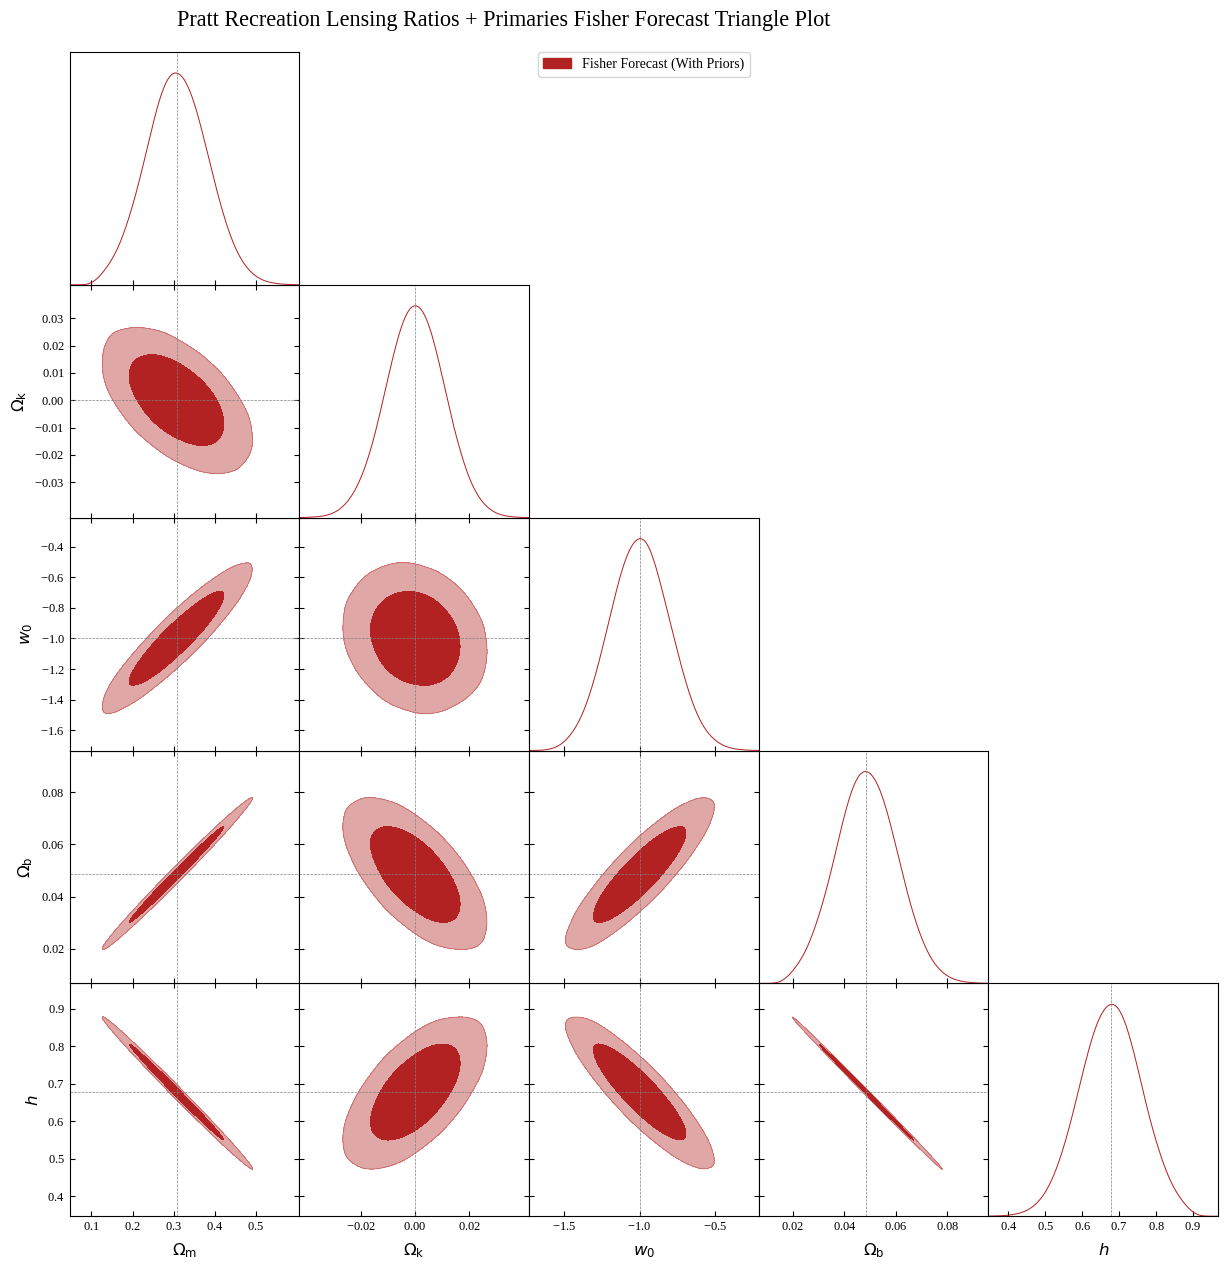

In [28]:
# Fisher forecast w/lensing ratios and primaries and five params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [27]:
## I start grasping at straws a bit more here... 

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.308\pm 0.064$ | $\Omega_m = 0.31^{+0.13}_{-0.13}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.064$ | $\Omega_m = 0.307 \pm 0.129$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.00\pm 0.20$ | $w_0 = -1.00^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.201$ | $w_0 = -1.000 \pm 0.401$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.0486\pm 0.0094$ | $\Omega_b = 0.049^{+0.019}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.0486 \pm 0.0095$ | $\Omega_b = 0.049 \pm 0.019$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.677\pm 0.067$ | $h = 0.68^{+0.13}_{-0.13}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.067$ | $h = 0.677 \pm 0.134$ |
| --- | --- | --- | --- |

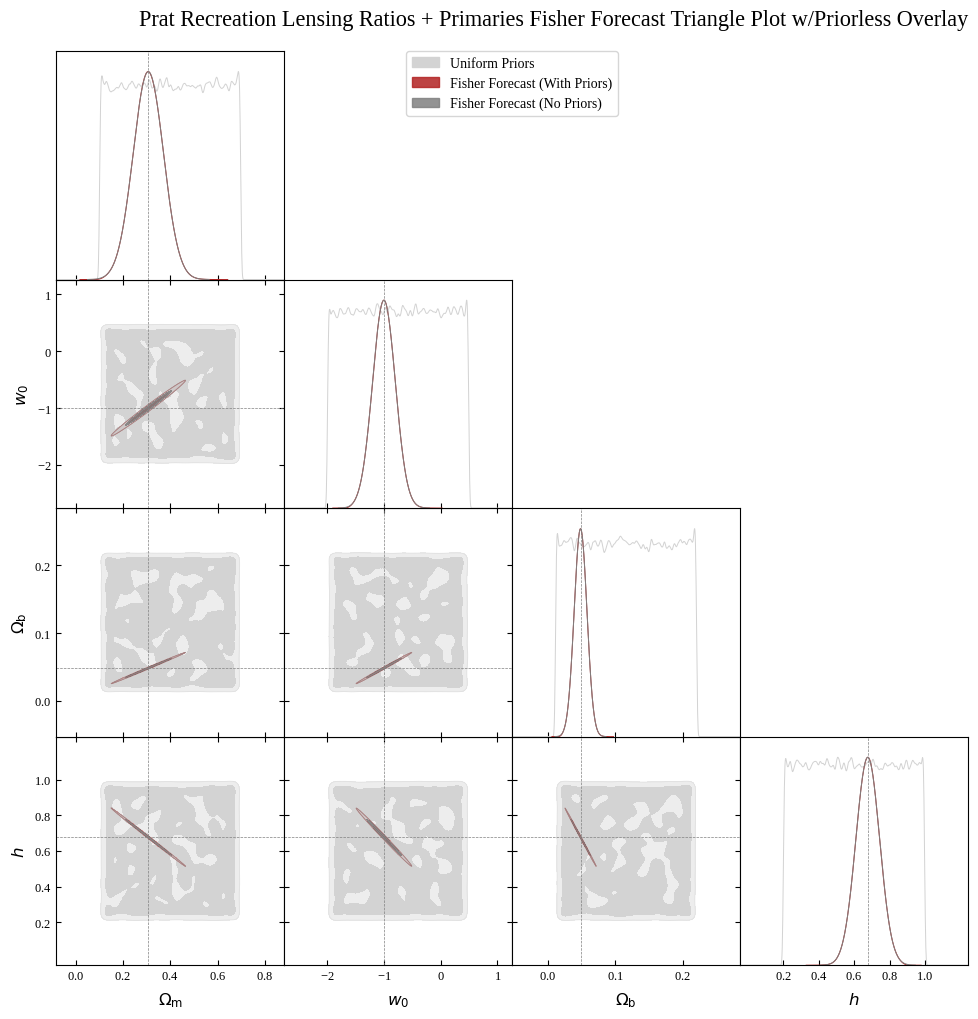

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


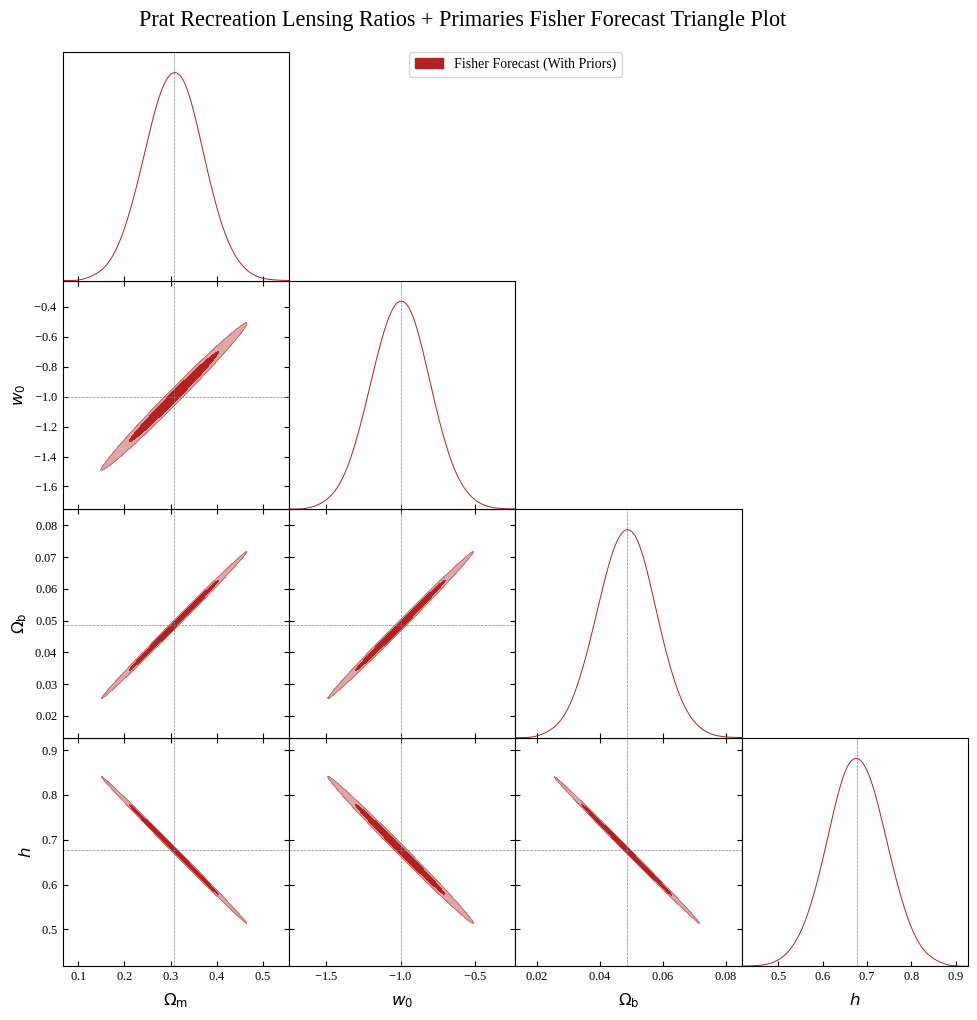

In [23]:
# Fisher forecast w/primaries and four params -- focus omega_m, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.308\pm 0.031$ | $\Omega_m = 0.308^{+0.060}_{-0.060}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.031$ | $\Omega_m = 0.307 \pm 0.061$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.000\pm 0.011$ | $\Omega_k = 0.000^{+0.021}_{-0.021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.011$ | $\Omega_k = 0.000 \pm 0.022$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.0486\pm 0.0060$ | $\Omega_b = 0.049^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.0486 \pm 0.0060$ | $\Omega_b = 0.049 \pm 0.012$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (With Priors) | $h = 0.677\pm 0.040$ | $h = 0.677^{+0.079}_{-0.079}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.040$ | $h = 0.677 \pm 0.081$ |
| --- | --- | --- | --- |

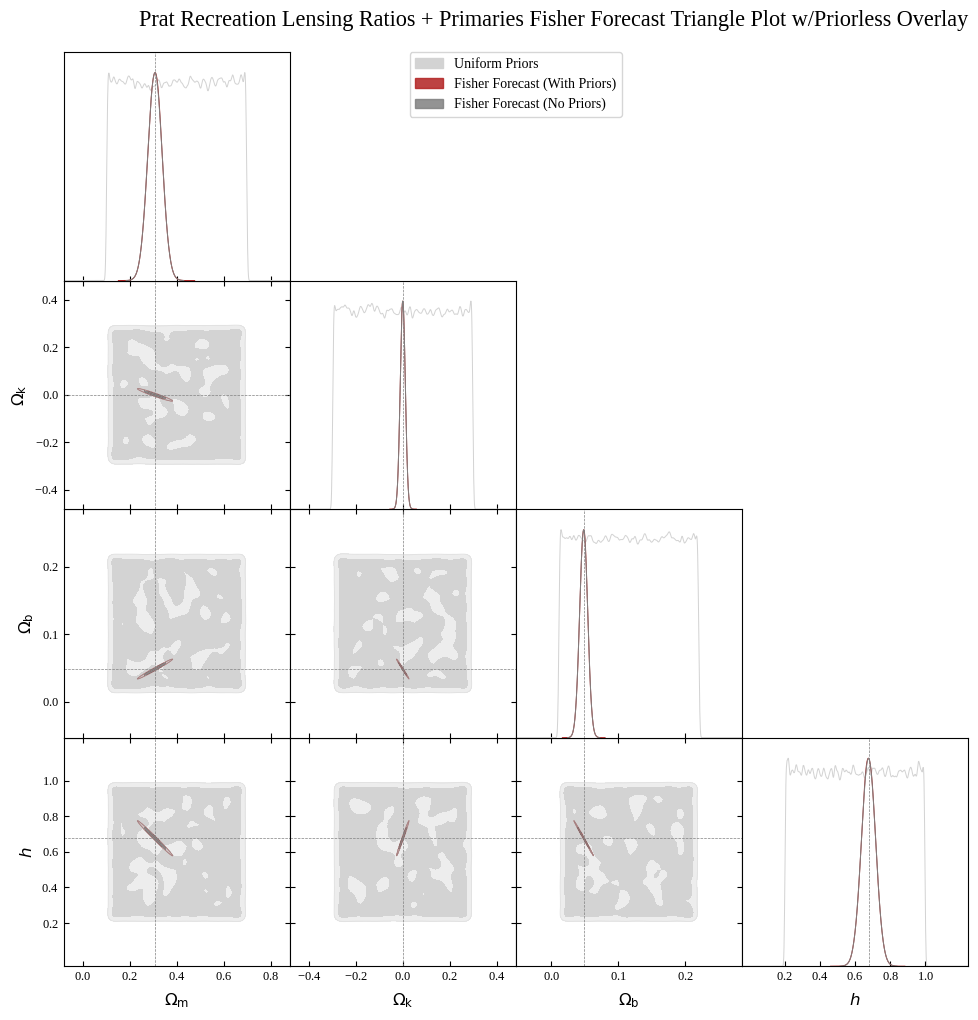

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


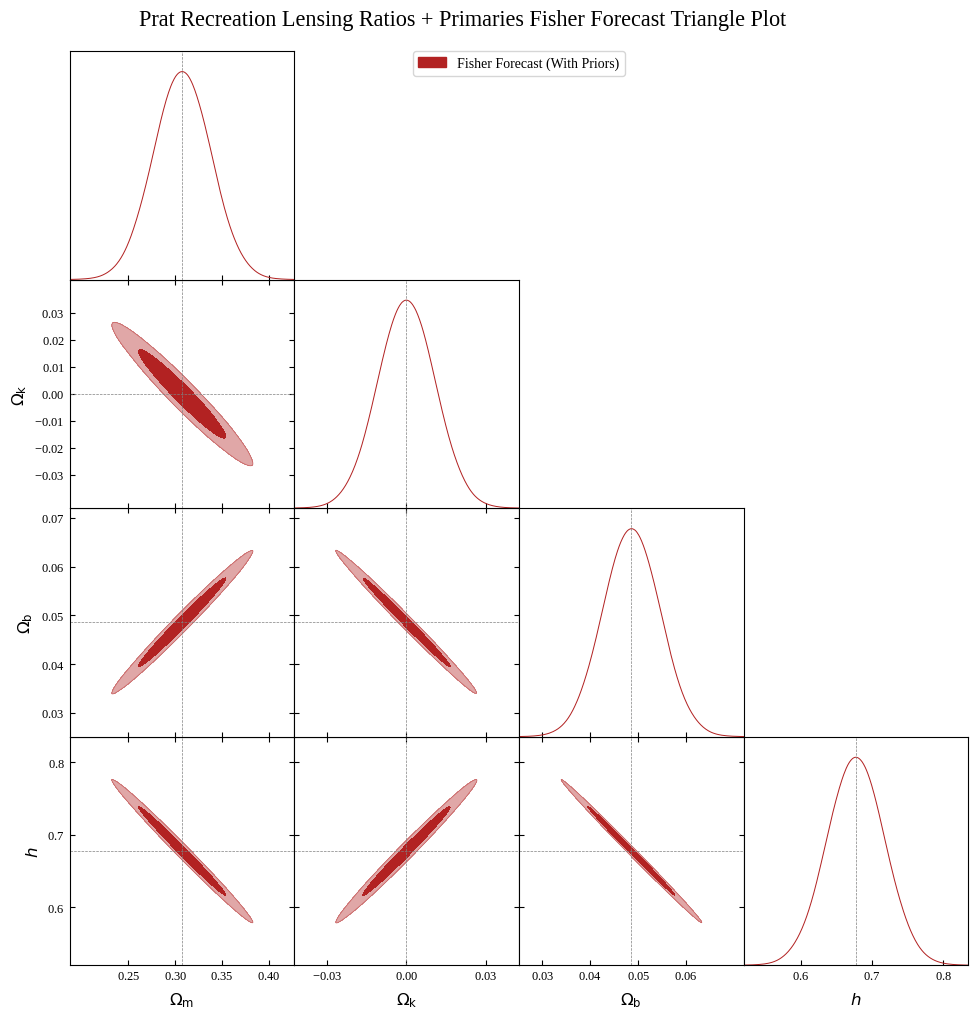

In [24]:
# Fisher forecast w/primaries and four params -- focus omega_m, omega_k

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0093$ | $\Omega_k = 0.000^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0093$ | $\Omega_k = 0.000 \pm 0.019$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.9999\pm 0.082$ | $w_0 = -1.00^{+0.16}_{-0.16}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.082$ | $w_0 = -1.000 \pm 0.164$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.0486\pm 0.0015$ | $\Omega_b = 0.0486^{+0.0030}_{-0.0030}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.0486 \pm 0.0015$ | $\Omega_b = 0.0486 \pm 0.0030$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0084$ | $h = 0.677^{+0.017}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0084$ | $h = 0.677 \pm 0.017$ |
| --- | --- | --- | --- |

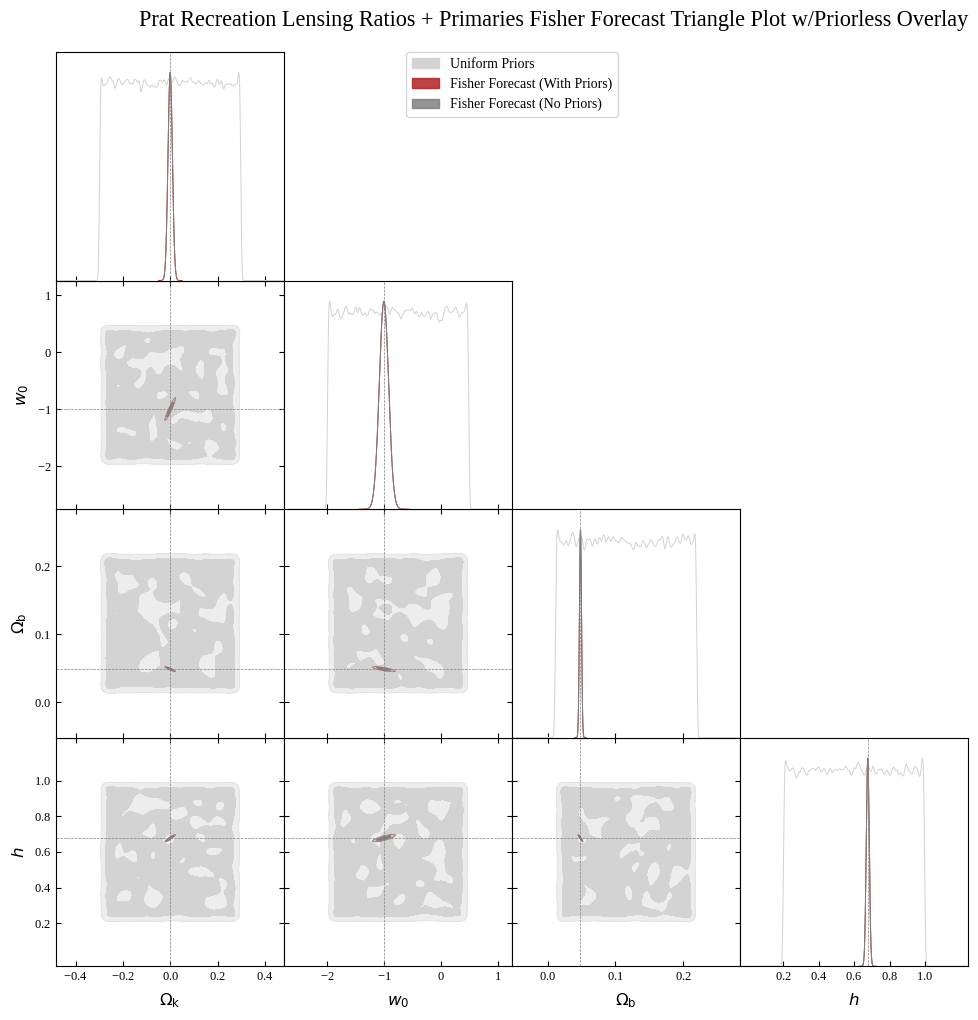

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


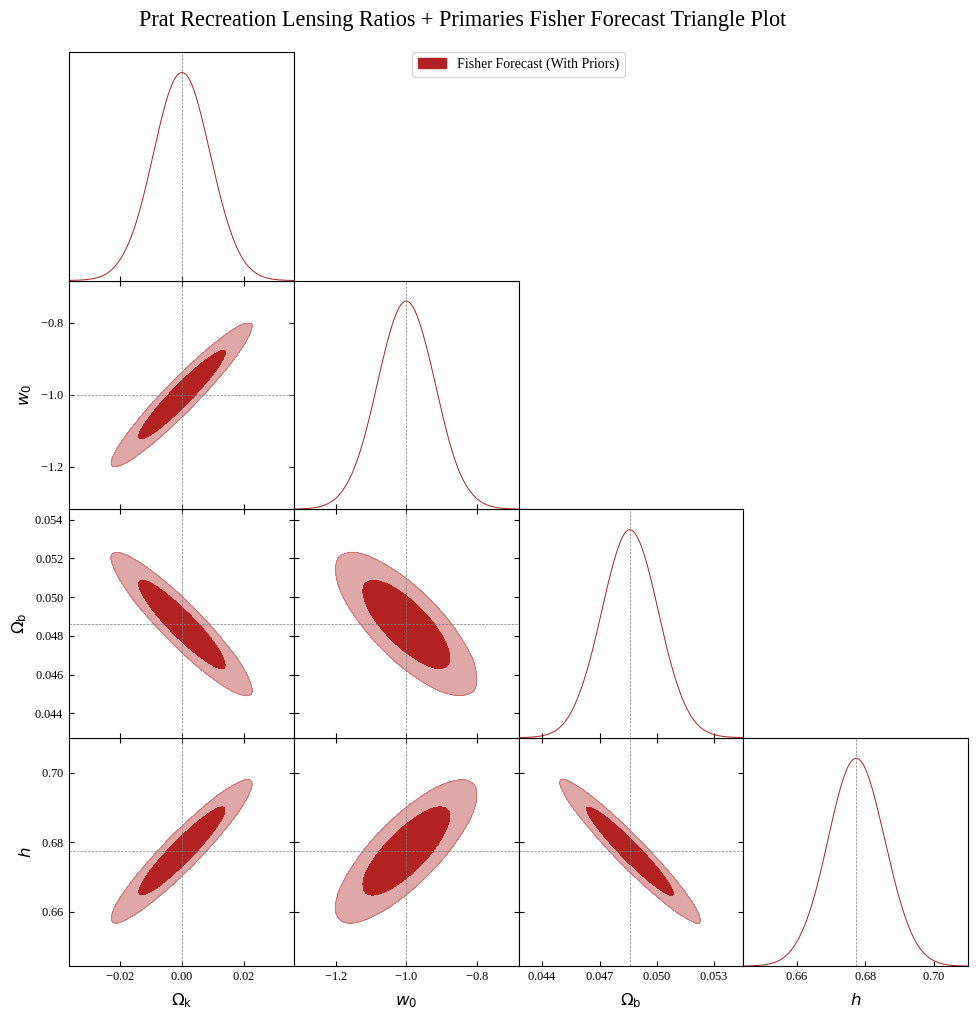

In [25]:
# Fisher forecast w/primaries and four params -- focus omega_k, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_k', 'w0', 'Omega_b', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0028$ | $\Omega_m = 0.3075^{+0.0055}_{-0.0055}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0028$ | $\Omega_m = 0.3075 \pm 0.0056$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.016$ | $w_0 = -1.000^{+0.030}_{-0.031}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.016$ | $w_0 = -1.000 \pm 0.031$ |
| --- | --- | --- | --- |

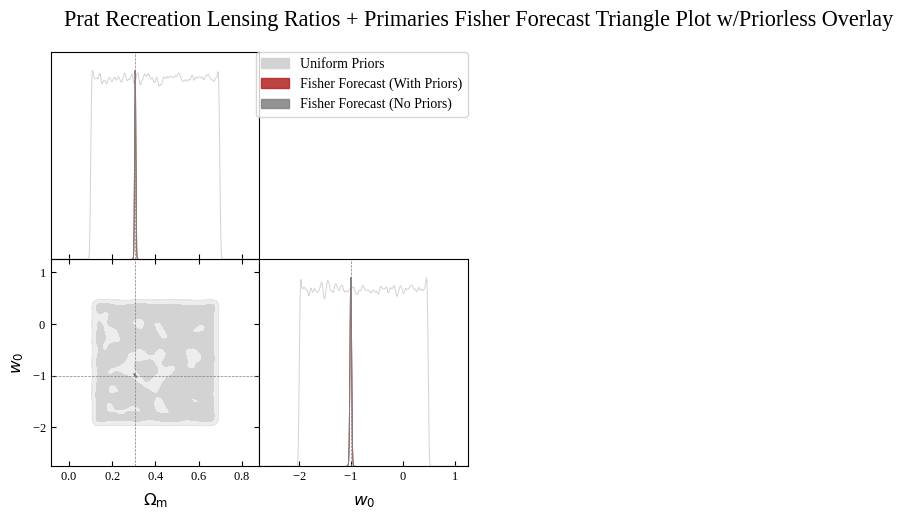

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


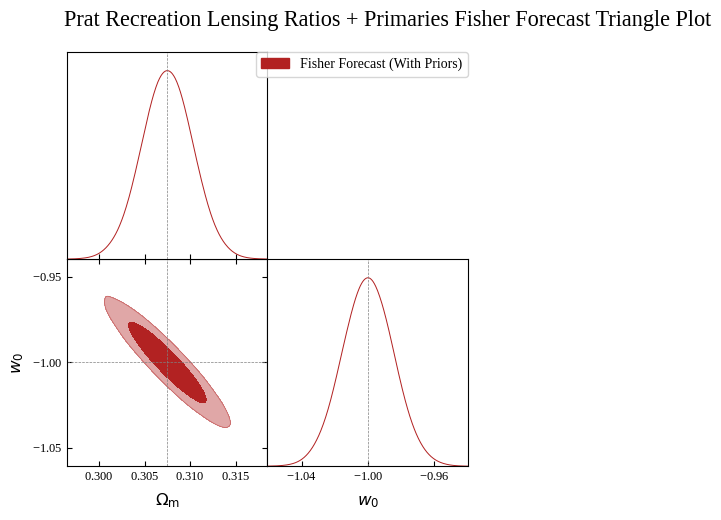

In [26]:
# Fisher forecast w/primaries and two params -- focus omega_m, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0038$ | $\Omega_m = 0.3075^{+0.0075}_{-0.0074}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0038$ | $\Omega_m = 0.3075 \pm 0.0076$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0013$ | $\Omega_k = 0.0000^{+0.0026}_{-0.0026}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0013$ | $\Omega_k = 0.0000 \pm 0.0026$ |
| --- | --- | --- | --- |

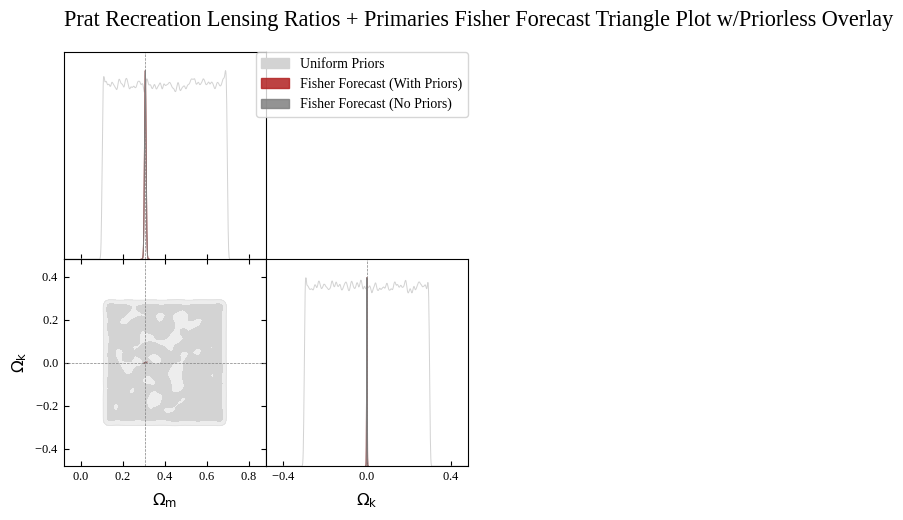

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


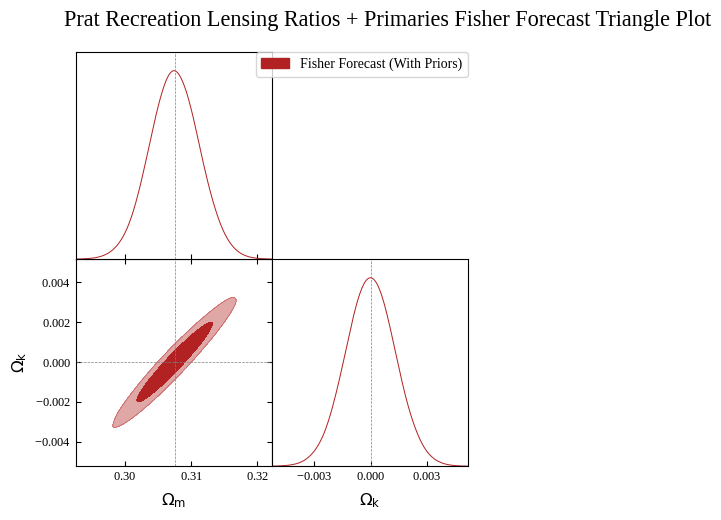

In [27]:
# Fisher forecast w/primaries and two params -- focus omega_m, omega_k

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0031$ | $\Omega_k = 0.0000^{+0.0061}_{-0.0062}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000 \pm 0.0031$ | $\Omega_k = 0.0000 \pm 0.0063$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.050$ | $w_0 = -1.000^{+0.097}_{-0.098}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.050$ | $w_0 = -1.000 \pm 0.100$ |
| --- | --- | --- | --- |

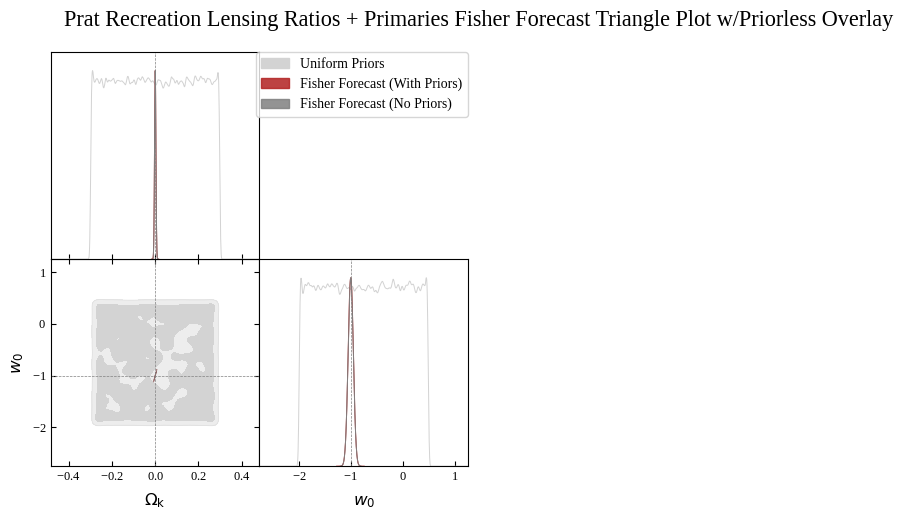

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


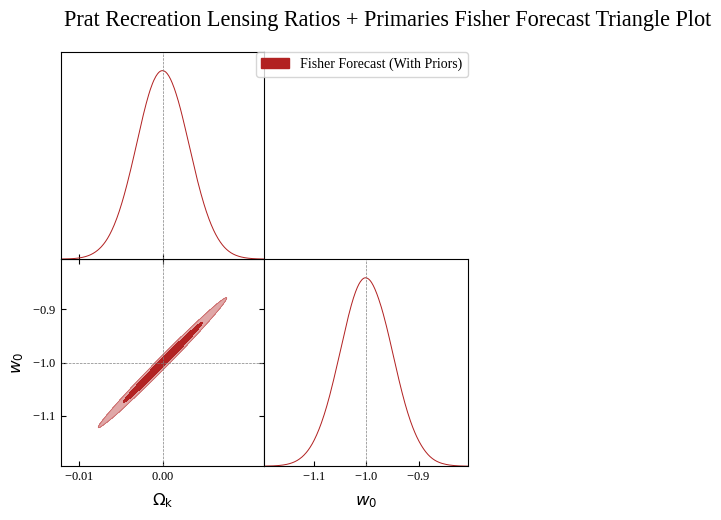

In [28]:
# Fisher forecast w/primaries and two params -- focus omega_k, w0

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_k', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.309\pm 0.078$ | $\Omega_m = 0.31^{+0.15}_{-0.15}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.079$ | $\Omega_m = 0.307 \pm 0.158$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.000\pm 0.013$ | $\Omega_k = 0.000^{+0.026}_{-0.026}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.013$ | $\Omega_k = 0.000 \pm 0.027$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.92\pm 0.28$ | $w_0 = -0.92^{+0.57}_{-0.53}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.316$ | $w_0 = -1.000 \pm 0.632$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.049\pm 0.012$ | $\Omega_b = 0.049^{+0.024}_{-0.024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.012$ | $\Omega_b = 0.049 \pm 0.025$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.675\pm 0.085$ | $h = 0.67^{+0.16}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.086$ | $h = 0.677 \pm 0.172$ |
| --- | --- | --- | --- |
| **$w_a$** | Uniform Priors | $w_a = -1.5\pm 1.2$ | $w_a = -1.5^{+1.9}_{-1.9}$ |
|  | Fisher Forecast (With Priors) | $w_a = -0.24^{+0.70}_{-0.22}$ | $w_a = -0.24^{+0.74}_{-0.89}$ |
|  | Fisher Forecast (No Priors) | $w_a = 0.000 \pm 0.637$ | $w_a = 0.000 \pm 1.274$ |
| --- | --- | --- | --- |
| **$A_s$** | Uniform Priors | $A_s = \left(\,3.5\pm 1.1\,\right)\cdot 10^{-9}$ | $A_s = \left(\,3.5^{+1.9}_{-1.9}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (With Priors) | $A_s = \left(\,2.140\pm 0.031\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.140^{+0.060}_{-0.060}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = 2.14 \cdot 10^{-9} \pm 3.09 \cdot 10^{-11}$ | $A_s = 2.14 \cdot 10^{-9} \pm 6.17 \cdot 10^{-11}$ |
| --- | --- | --- | --- |
| **$n_s$** | Uniform Priors | $n_s = 1.000\pm 0.058$ | $n_s = 1.000^{+0.095}_{-0.095}$ |
|  | Fisher Forecast (With Priors) | $n_s = 0.967\pm 0.015$ | $n_s = 0.967^{+0.030}_{-0.030}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.967 \pm 0.015$ | $n_s = 0.967 \pm 0.031$ |
| --- | --- | --- | --- |

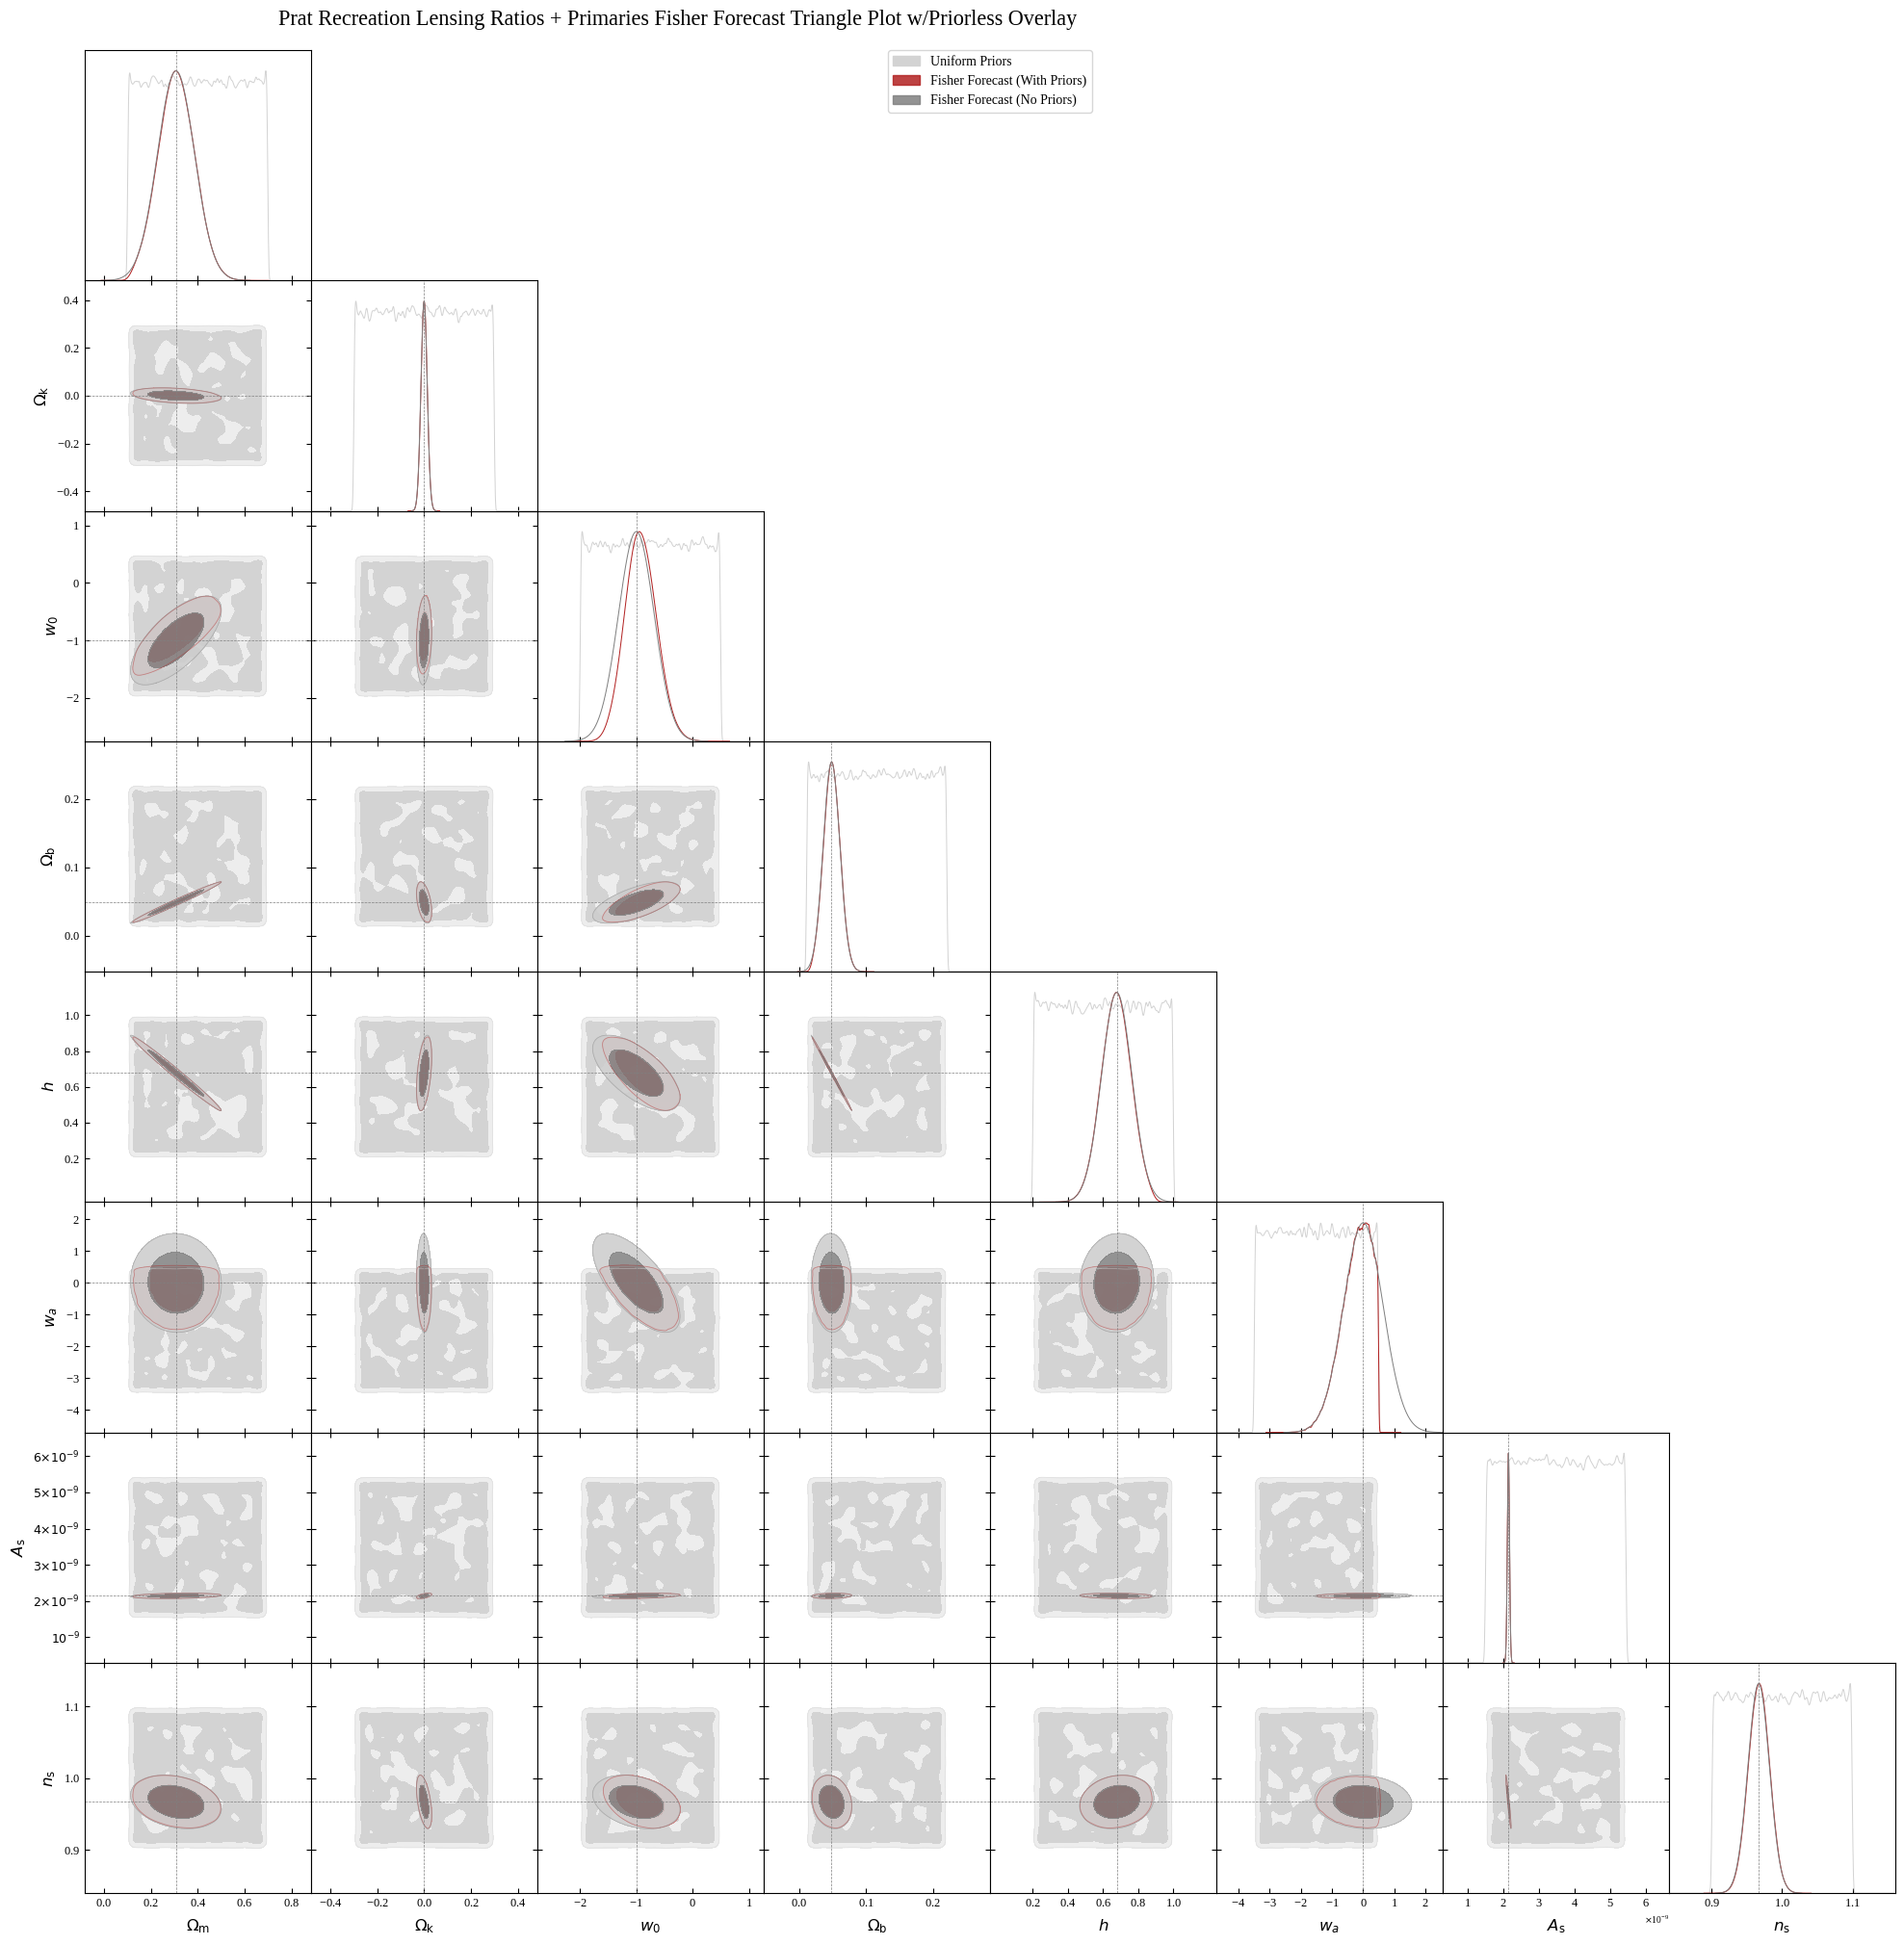

Plot successfully saved to: plots/Fisher Forecasts/prat_recreation_lensing_ratios_+_primaries_fisher_forecast_triangle_plot.pdf


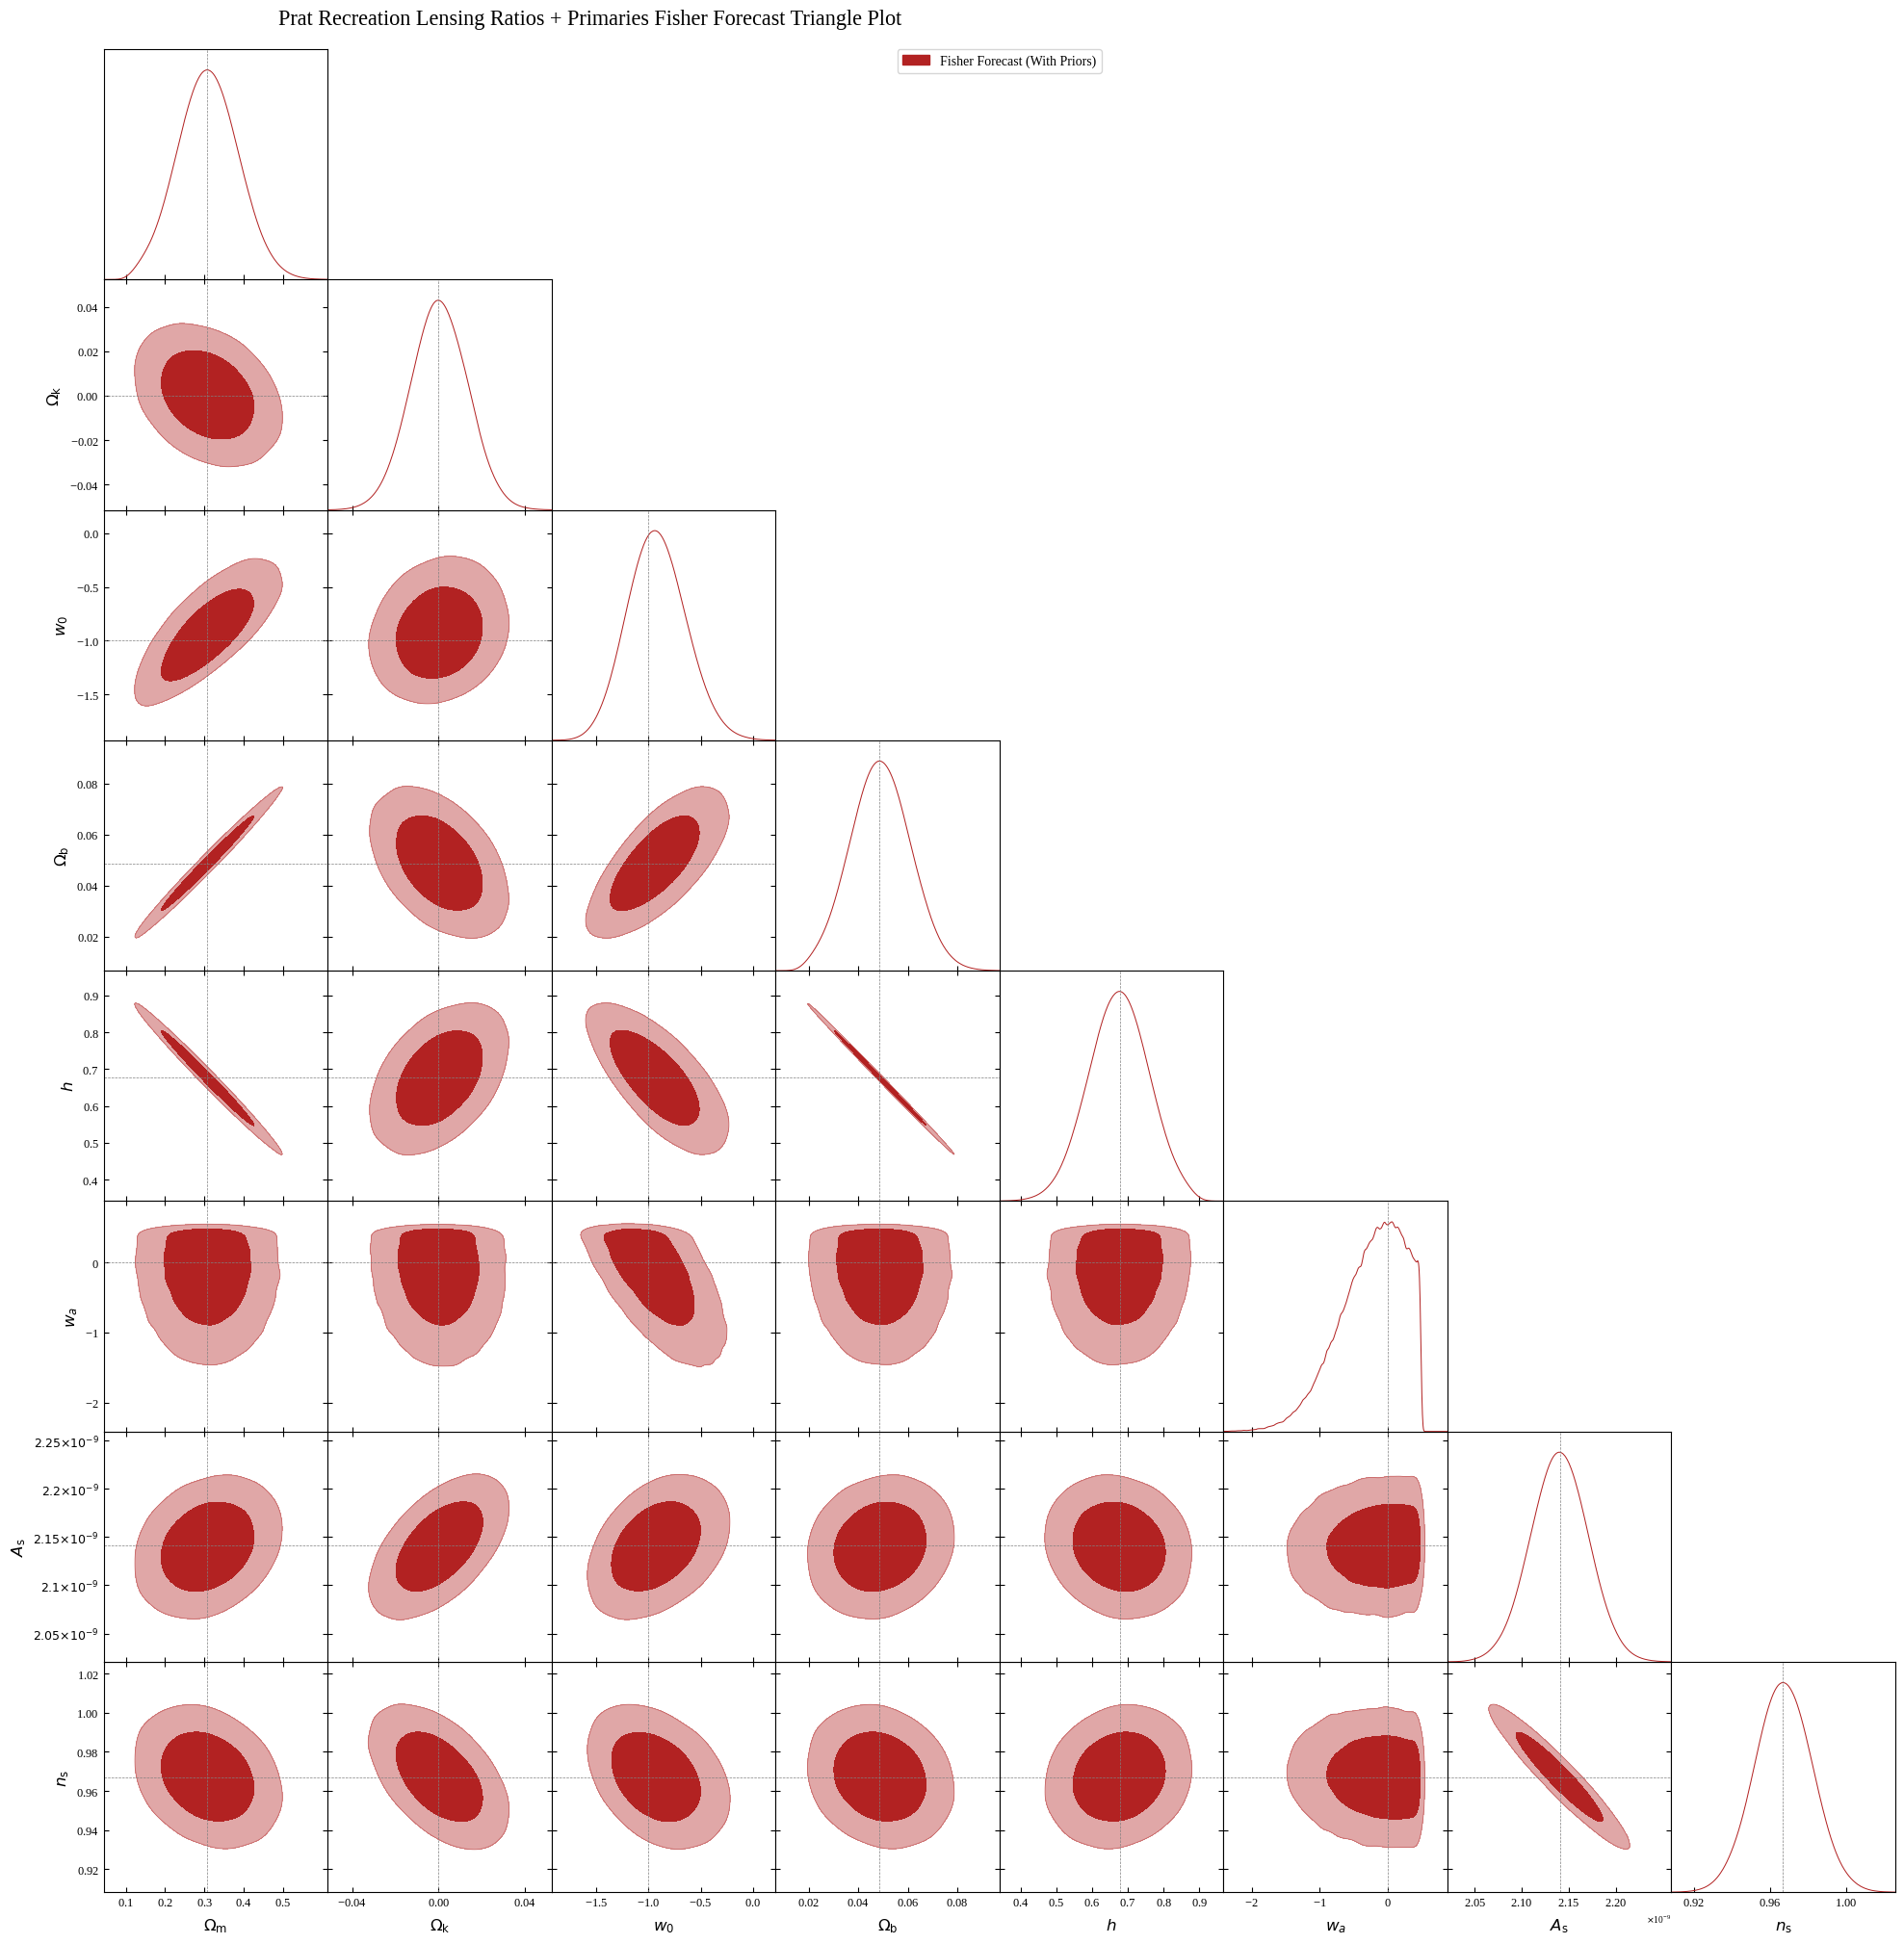

In [31]:
# Fisher forecast w/lensing ratios and primaries and all params

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
    'Omega_k': (-0.3, 0.3),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'wa': (-3.5, 0.5),
    'A_s': (1.48797e-9, 5.45981e-9),
    'n_s': (0.9, 1.1)
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=Prat_lens_data,
    source_data=Prat_source_data,
    binsize=50,
    n_ell = 3000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=Prat_cmb_noise,
    cmb_noise_TT=medium_l_SO_cmb_noise_TT,
    cmb_noise_EE=medium_l_SO_cmb_noise_EE,
    cmb_noise_TE=medium_l_SO_cmb_noise_TE,
    shot_noise_lens=Prat_shot_noise,
    shape_noise_source=Prat_shape_noise,
    desired_spectra = ['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'Omega_k', 'w0', 'Omega_b', 'h', 'wa', 'A_s', 'n_s']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="Prat Recreation Lensing Ratios + Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

In [24]:
# Thoughts
# The direction of the degeneracies is different than it is in Prat
# I've made several guesses along the way, but still I really don't like that
# The Fisher and MCMC agree very well, so I think the problem is in the shared parts of those pipelines, 
# namely in the covariance or vector building
# It would be interesting to find some prebuilt covariance matrix 
# and then try to build one with the same parameters and see what happens

## I sampled over wa when I meant to sample over w0
## This might not fix the degeneracy direciton, but I'll not that the direction switches when I go from lensing ratios to full
# so maybe just maybethe drectionof omega_m w0 will swap too and then will point more the way I want it to
## that did not fix it 
# I wonder why wa flips but w0 does not
# it also seems like generally the w0/Omega_m degeneracy should point NW, so something is definitely going wrong

# indeed every degeneracy slant is wrong -- if they all changed directions things would be ok
# so something systematic seems to be afoot

In [29]:
# calculate Prat data vector and covariance vector

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for Prat LSST + CMB-S4...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 3000
binsize = 50
magnification_bias_lenses = None
desired_spectra = ['GL', 'CG', 'TT', 'TE', 'EE']

cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        Prat_lens_data,
        Prat_source_data,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=Prat_shot_noise,
        shape_noise_source=Prat_shape_noise,
        cmb_noise_kk=medium_l_SO_cmb_noise_kk,
        cmb_noise_TT=medium_l_SO_cmb_noise_TT,
        cmb_noise_EE=medium_l_SO_cmb_noise_EE,
        cmb_noise_TE=medium_l_SO_cmb_noise_TE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries=True,
        z_max=6,
        n_chi=1024
    )

print("produced f_map pairs: ", f_map.pairs)

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/Prat_data_vector.npy'
covariance_filename = 'cobaya_data/Prat_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# --- Quick Sanity Check ---
print(f"Vector Shape:      {observed_data_vector.shape}")
print(f"Covariance Shape:  {covariance_matrix.shape}")

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for Pratt LSST + CMB-S4...
produced f_map pairs:  [('E', 'E'), ('E', 'T'), ('T', 'T'), ('g1', 'kappa_c'), ('g1', 'kappa_g1'), ('g10', 'kappa_c'), ('g10', 'kappa_g1'), ('g2', 'kappa_c'), ('g2', 'kappa_g1'), ('g3', 'kappa_c'), ('g3', 'kappa_g1'), ('g4', 'kappa_c'), ('g4', 'kappa_g1'), ('g5', 'kappa_c'), ('g5', 'kappa_g1'), ('g6', 'kappa_c'), ('g6', 'kappa_g1'), ('g7', 'kappa_c'), ('g7', 'kappa_g1'), ('g8', 'kappa_c'), ('g8', 'kappa_g1'), ('g9', 'kappa_c'), ('g9', 'kappa_g1')]
Vector Shape:      (1380,)
Covariance Shape:  (1380, 1380)
Fiducial data vector saved to: cobaya_data/Pratt_data_vector.npy
Covariance matrix saved to: cobaya_data/Pratt_covariance_matrix.npy


In [22]:
# plot chi2 for Prat likelihood

# initialize
info = "yaml/Prat_likelihood.yaml"
model = get_model(info)
likelihood_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood"]

# set grids and chi2 matrix
omega_m_grid = np.linspace(0.2, 0.4, 20)
omega_k_grid = np.linspace(-0.1, 0.1, 20)
w0_grid = np.linspace(-1.2, -0.8, 20)
chi2_matrix = np.zeros((len(omega_m_grid), len(omega_m_grid), len(w0_grid)))

# create a counter
step = 0
total_steps = len(omega_m_grid) * len(omega_k_grid) * len(w0_grid)

print("Starting 3D grid scan...")
for i, om in enumerate(omega_m_grid):
    for j, ok in enumerate(omega_k_grid):
        for k, w in enumerate(w0_grid):
            
            step += 1
            if step % 100 == 0:  # Prints an update every 100 points
                print(f"Evaluating step {step}/{total_steps}...")
    
            chi2 = likelihood_object.profile_chi2(
                Omega_m=om,
                Omega_b=0.04859,
                h=0.6774,
                A_s=2.141e-9,
                n_s=0.9667,
                w0=w,
                wa=0.0,
                Omega_k=ok
            )
            chi2_matrix[i, j, k] = chi2

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
Not using emulator.
Spectra considered:  ['GL', 'CG', 'TT', 'TE', 'EE']
  Loading lens shot noise from: data/Pratt_shot_noise.npy
  Loading source shape noise from: data/Pratt_shape_noise.npy
  Loading CMB noise from: data/medium_l_SO_cmb_noise_kk.npy
  Loading CMB noise from: data/medium_l_SO_cmb_noise_TT.npy
  Loading CMB noise from: data/medium_l_SO_cmb_noise_EE.npy
  Loading CMB noise from: data/medium_l_SO_cmb_noise_TE.npy
  Loaded lens data from data/Pratt_lens_data.npy
  Loaded source data from: data/Pratt_source_data.npy
  Loading observed data vector from: cobaya_data/Pratt_data_vector.npy
  Loading covariance matrix from: cobaya_data/Pratt_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting 3D grid scan...
Evaluating step 100/8000...
Evaluating step 200/8000...


KeyboardInterrupt: 

In [ ]:
# Plot chi2

# plot
# 1. Find the global minimum across the entire 3D matrix
min_chi2 = np.min(chi2_matrix)

# 2. Profile out the third dimension for each pair by taking the minimum along that axis
# Axis mapping based on your loop: 0 = Omega_m, 1 = Omega_k, 2 = w0

# Pair A: Omega_m vs Omega_k (Profile out w0 -> Axis 2)
chi2_om_ok = np.min(chi2_matrix, axis=2)
delta_chi2_om_ok = chi2_om_ok - min_chi2

# Pair B: Omega_m vs w0 (Profile out Omega_k -> Axis 1)
chi2_om_w0 = np.min(chi2_matrix, axis=1)
delta_chi2_om_w0 = chi2_om_w0 - min_chi2

# Pair C: Omega_k vs w0 (Profile out Omega_m -> Axis 0)
chi2_ok_w0 = np.min(chi2_matrix, axis=0)
delta_chi2_ok_w0 = chi2_ok_w0 - min_chi2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
levels = [2.30, 6.18]  # 1-sigma and 2-sigma for 2 joint parameters
fmt_dict = {2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}

# --- Plot 1: Omega_m vs Omega_k ---
# Note: contour expects (X_grid, Y_grid, Z_matrix) 
# Since chi2_matrix was filled as [i, j, k], the remaining 2D slice is [i, j] -> (Omega_m, Omega_k)
# Meshgrid layout or matching index: X=omega_k_grid (cols), Y=omega_m_grid (rows)
contour1 = axes[0].contour(omega_k_grid, omega_m_grid, delta_chi2_om_ok, levels=levels, colors=['firebrick', 'navy'], linewidths=2)
axes[0].clabel(contour1, inline=True, fmt=fmt_dict, fontsize=10)
axes[0].plot(0.0, 0.2589, marker='x', color='black', markersize=8, label='Fiducial') # Prat values
axes[0].set_xlabel(r"$\Omega_k$")
axes[0].set_ylabel(r"$\Omega_m$")
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Omega_m vs w0 ---
# Remaining 2D slice is [i, k] -> (Omega_m, w0)
contour2 = axes[1].contour(w0_grid, omega_m_grid, delta_chi2_om_w0, levels=levels, colors=['firebrick', 'navy'], linewidths=2)
axes[1].clabel(contour2, inline=True, fmt=fmt_dict, fontsize=10)
axes[1].plot(-1.0, 0.2589, marker='x', color='black', markersize=8)
axes[1].set_xlabel(r"$w_0$")
axes[1].set_ylabel(r"$\Omega_m$")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Omega_k vs w0 ---
# Remaining 2D slice is [j, k] -> (Omega_k, w0)
contour3 = axes[2].contour(w0_grid, omega_k_grid, delta_chi2_ok_w0, levels=levels, colors=['firebrick', 'navy'], linewidths=2)
axes[2].clabel(contour3, inline=True, fmt=fmt_dict, fontsize=10)
axes[2].plot(-1.0, 0.0, marker='x', color='black', markersize=8)
axes[2].set_xlabel(r"$w_0$")
axes[2].set_ylabel(r"$\Omega_k$")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Profiled 2D $\chi^2$ Contours for Prat Reconstruction", fontsize=14, y=1.02)
axes[0].legend()
plt.tight_layout()
plt.show()

### SO Fisher -- Primaries Only

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0031$ | $\Omega_m = 0.3075^{+0.0061}_{-0.0062}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0031$ | $\Omega_m = 0.3075 \pm 0.0063$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.75\pm 0.72$ | $w_0 = -0.7^{+1.2}_{-1.2}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -1.000\pm 0.013$ | $w_0 = -1.000^{+0.026}_{-0.025}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.013$ | $w_0 = -1.000 \pm 0.026$ |
| --- | --- | --- | --- |

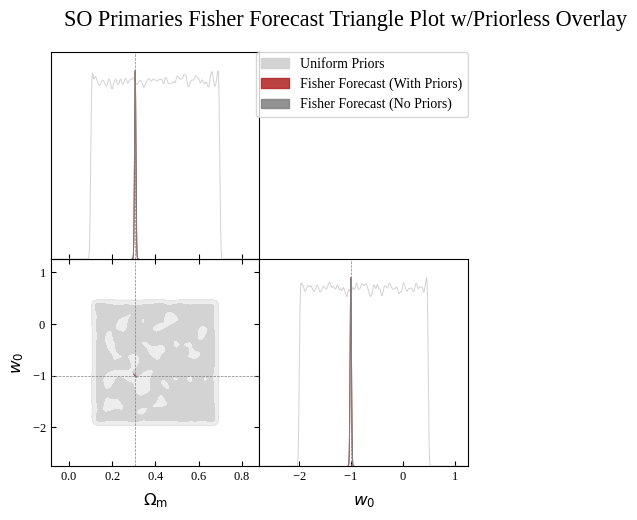

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot.pdf


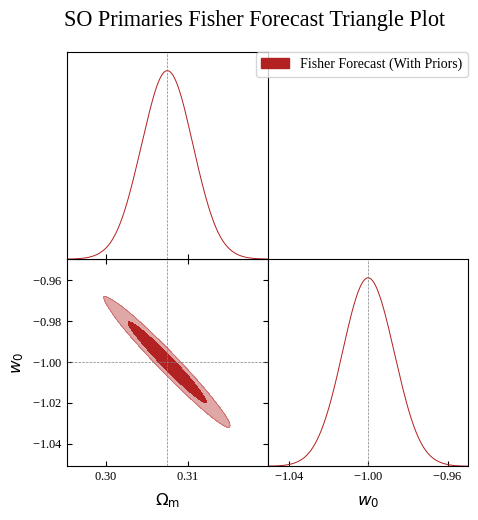

In [17]:
# Primaries only Fisher

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'w0': (-2, 0.5),
}

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params = ['Omega_m', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="SO Primaries Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=params,
    title="SO Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    plot_prior = False
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/so_primares_full_param_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.34^{+0.11}_{-0.15}$ | $\Omega_m = 0.34^{+0.22}_{-0.23}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.307 \pm 0.155$ | $\Omega_m = 0.307 \pm 0.310$ |
| --- | --- | --- | --- |
| **$w_a$** | Uniform Priors | $w_a = -1.5\pm 1.2$ | $w_a = -1.5^{+1.9}_{-1.9}$ |
|  | Fisher Forecast (With Priors) | $w_a = -1.13^{+1.6}_{-0.52}$ | $w_a = -1.1^{+1.6}_{-1.9}$ |
|  | Fisher Forecast (No Priors) | $w_a = 0.000 \pm 2.229$ | $w_a = 0.000 \pm 4.457$ |
| --- | --- | --- | --- |
| **$w_0$** | Uniform Priors | $w_0 = -0.50\pm 0.58$ | $w_0 = -0.50^{+0.95}_{-0.95}$ |
|  | Fisher Forecast (With Priors) | $w_0 = -0.56^{+0.45}_{-0.53}$ | $w_0 = -0.56^{+0.85}_{-0.85}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.000 \pm 0.872$ | $w_0 = -1.000 \pm 1.744$ |
| --- | --- | --- | --- |
| **$A_s$** | Uniform Priors | $A_s = \left(\,3.5\pm 1.1\,\right)\cdot 10^{-9}$ | $A_s = \left(\,3.5^{+1.9}_{-1.9}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (With Priors) | $A_s = \left(\,2.143\pm 0.036\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.143^{+0.070}_{-0.070}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = 2.14 \cdot 10^{-9} \pm 3.39 \cdot 10^{-11}$ | $A_s = 2.14 \cdot 10^{-9} \pm 6.78 \cdot 10^{-11}$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.65^{+0.16}_{-0.12}$ | $h = 0.65^{+0.24}_{-0.25}$ |
|  | Fisher Forecast (No Priors) | $h = 0.677 \pm 0.169$ | $h = 0.677 \pm 0.338$ |
| --- | --- | --- | --- |
| **$\Omega_b$** | Uniform Priors | $\Omega_b = 0.116\pm 0.061$ | $\Omega_b = 0.12^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (With Priors) | $\Omega_b = 0.053^{+0.017}_{-0.023}$ | $\Omega_b = 0.053^{+0.036}_{-0.035}$ |
|  | Fisher Forecast (No Priors) | $\Omega_b = 0.049 \pm 0.024$ | $\Omega_b = 0.049 \pm 0.048$ |
| --- | --- | --- | --- |
| **$n_s$** | Uniform Priors | $n_s = 1.000\pm 0.058$ | $n_s = 1.000^{+0.095}_{-0.095}$ |
|  | Fisher Forecast (With Priors) | $n_s = 0.966\pm 0.017$ | $n_s = 0.966^{+0.032}_{-0.032}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.967 \pm 0.017$ | $n_s = 0.967 \pm 0.034$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Uniform Priors | $\Omega_k = 0.00\pm 0.17$ | $\Omega_k = 0.00^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_k = 0.002\pm 0.015$ | $\Omega_k = 0.002^{+0.029}_{-0.029}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000 \pm 0.016$ | $\Omega_k = 0.000 \pm 0.033$ |
| --- | --- | --- | --- |

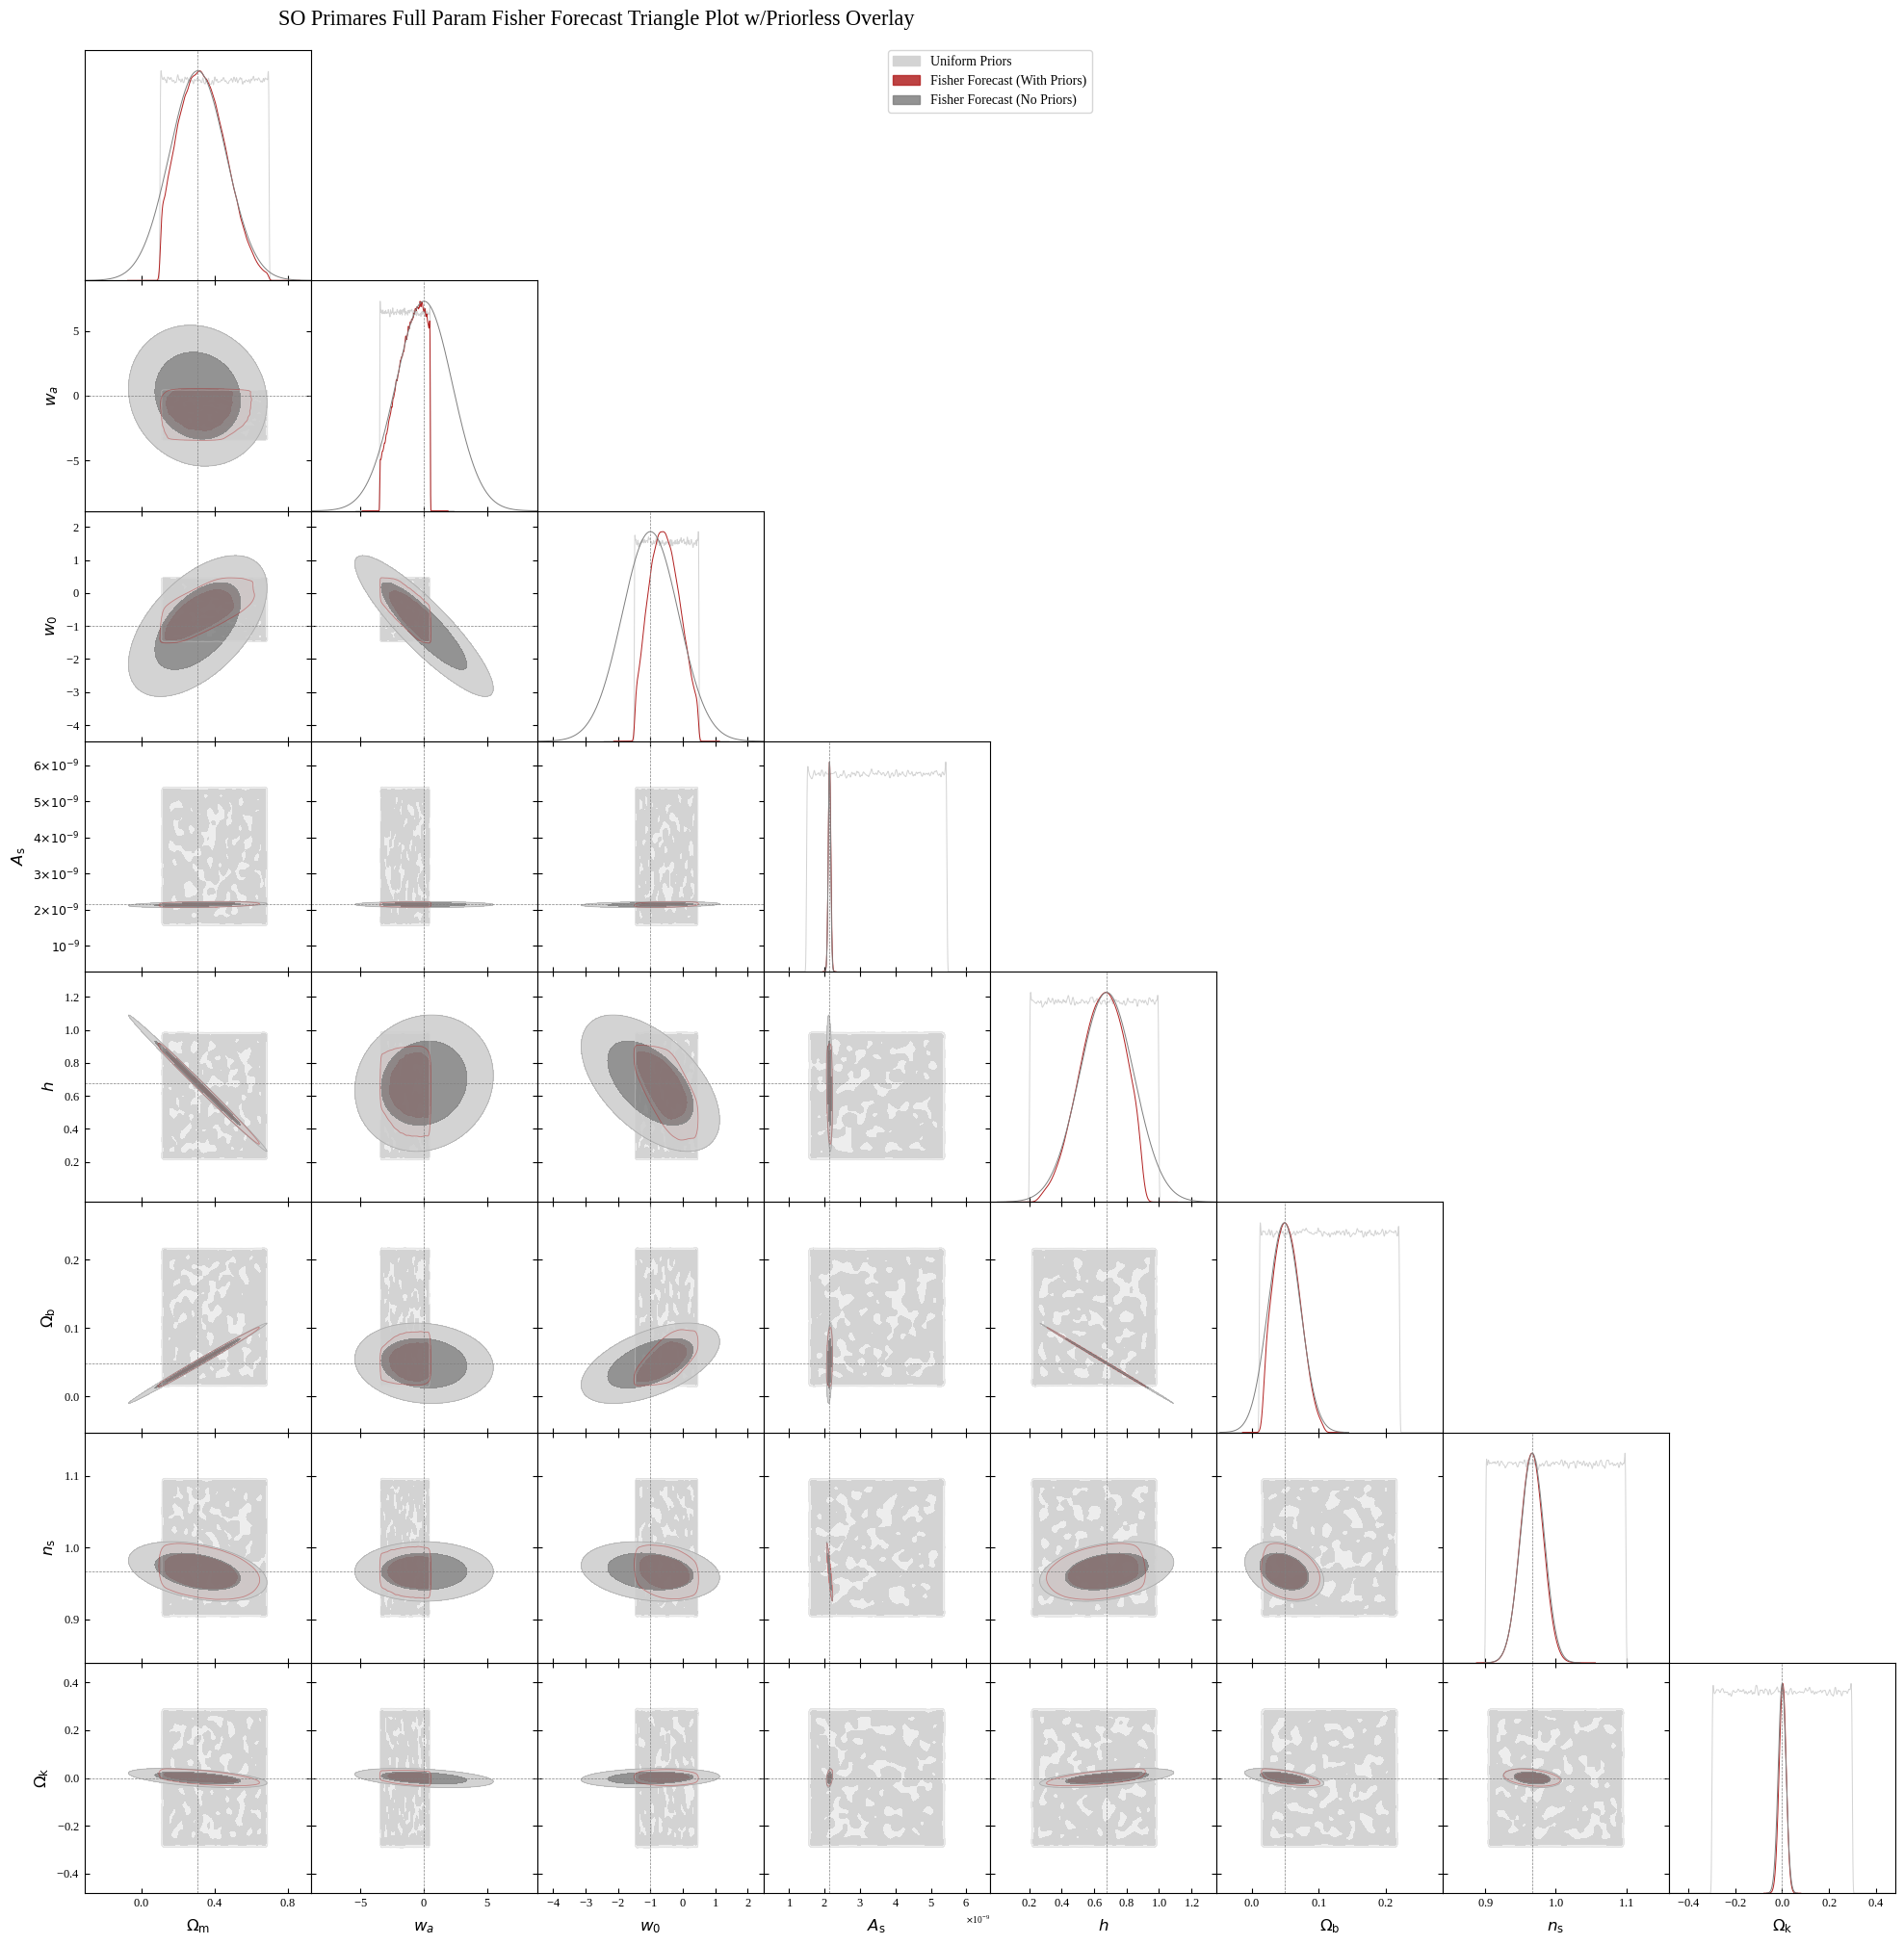

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_full_param_fisher_forecast_triangle_plot.pdf


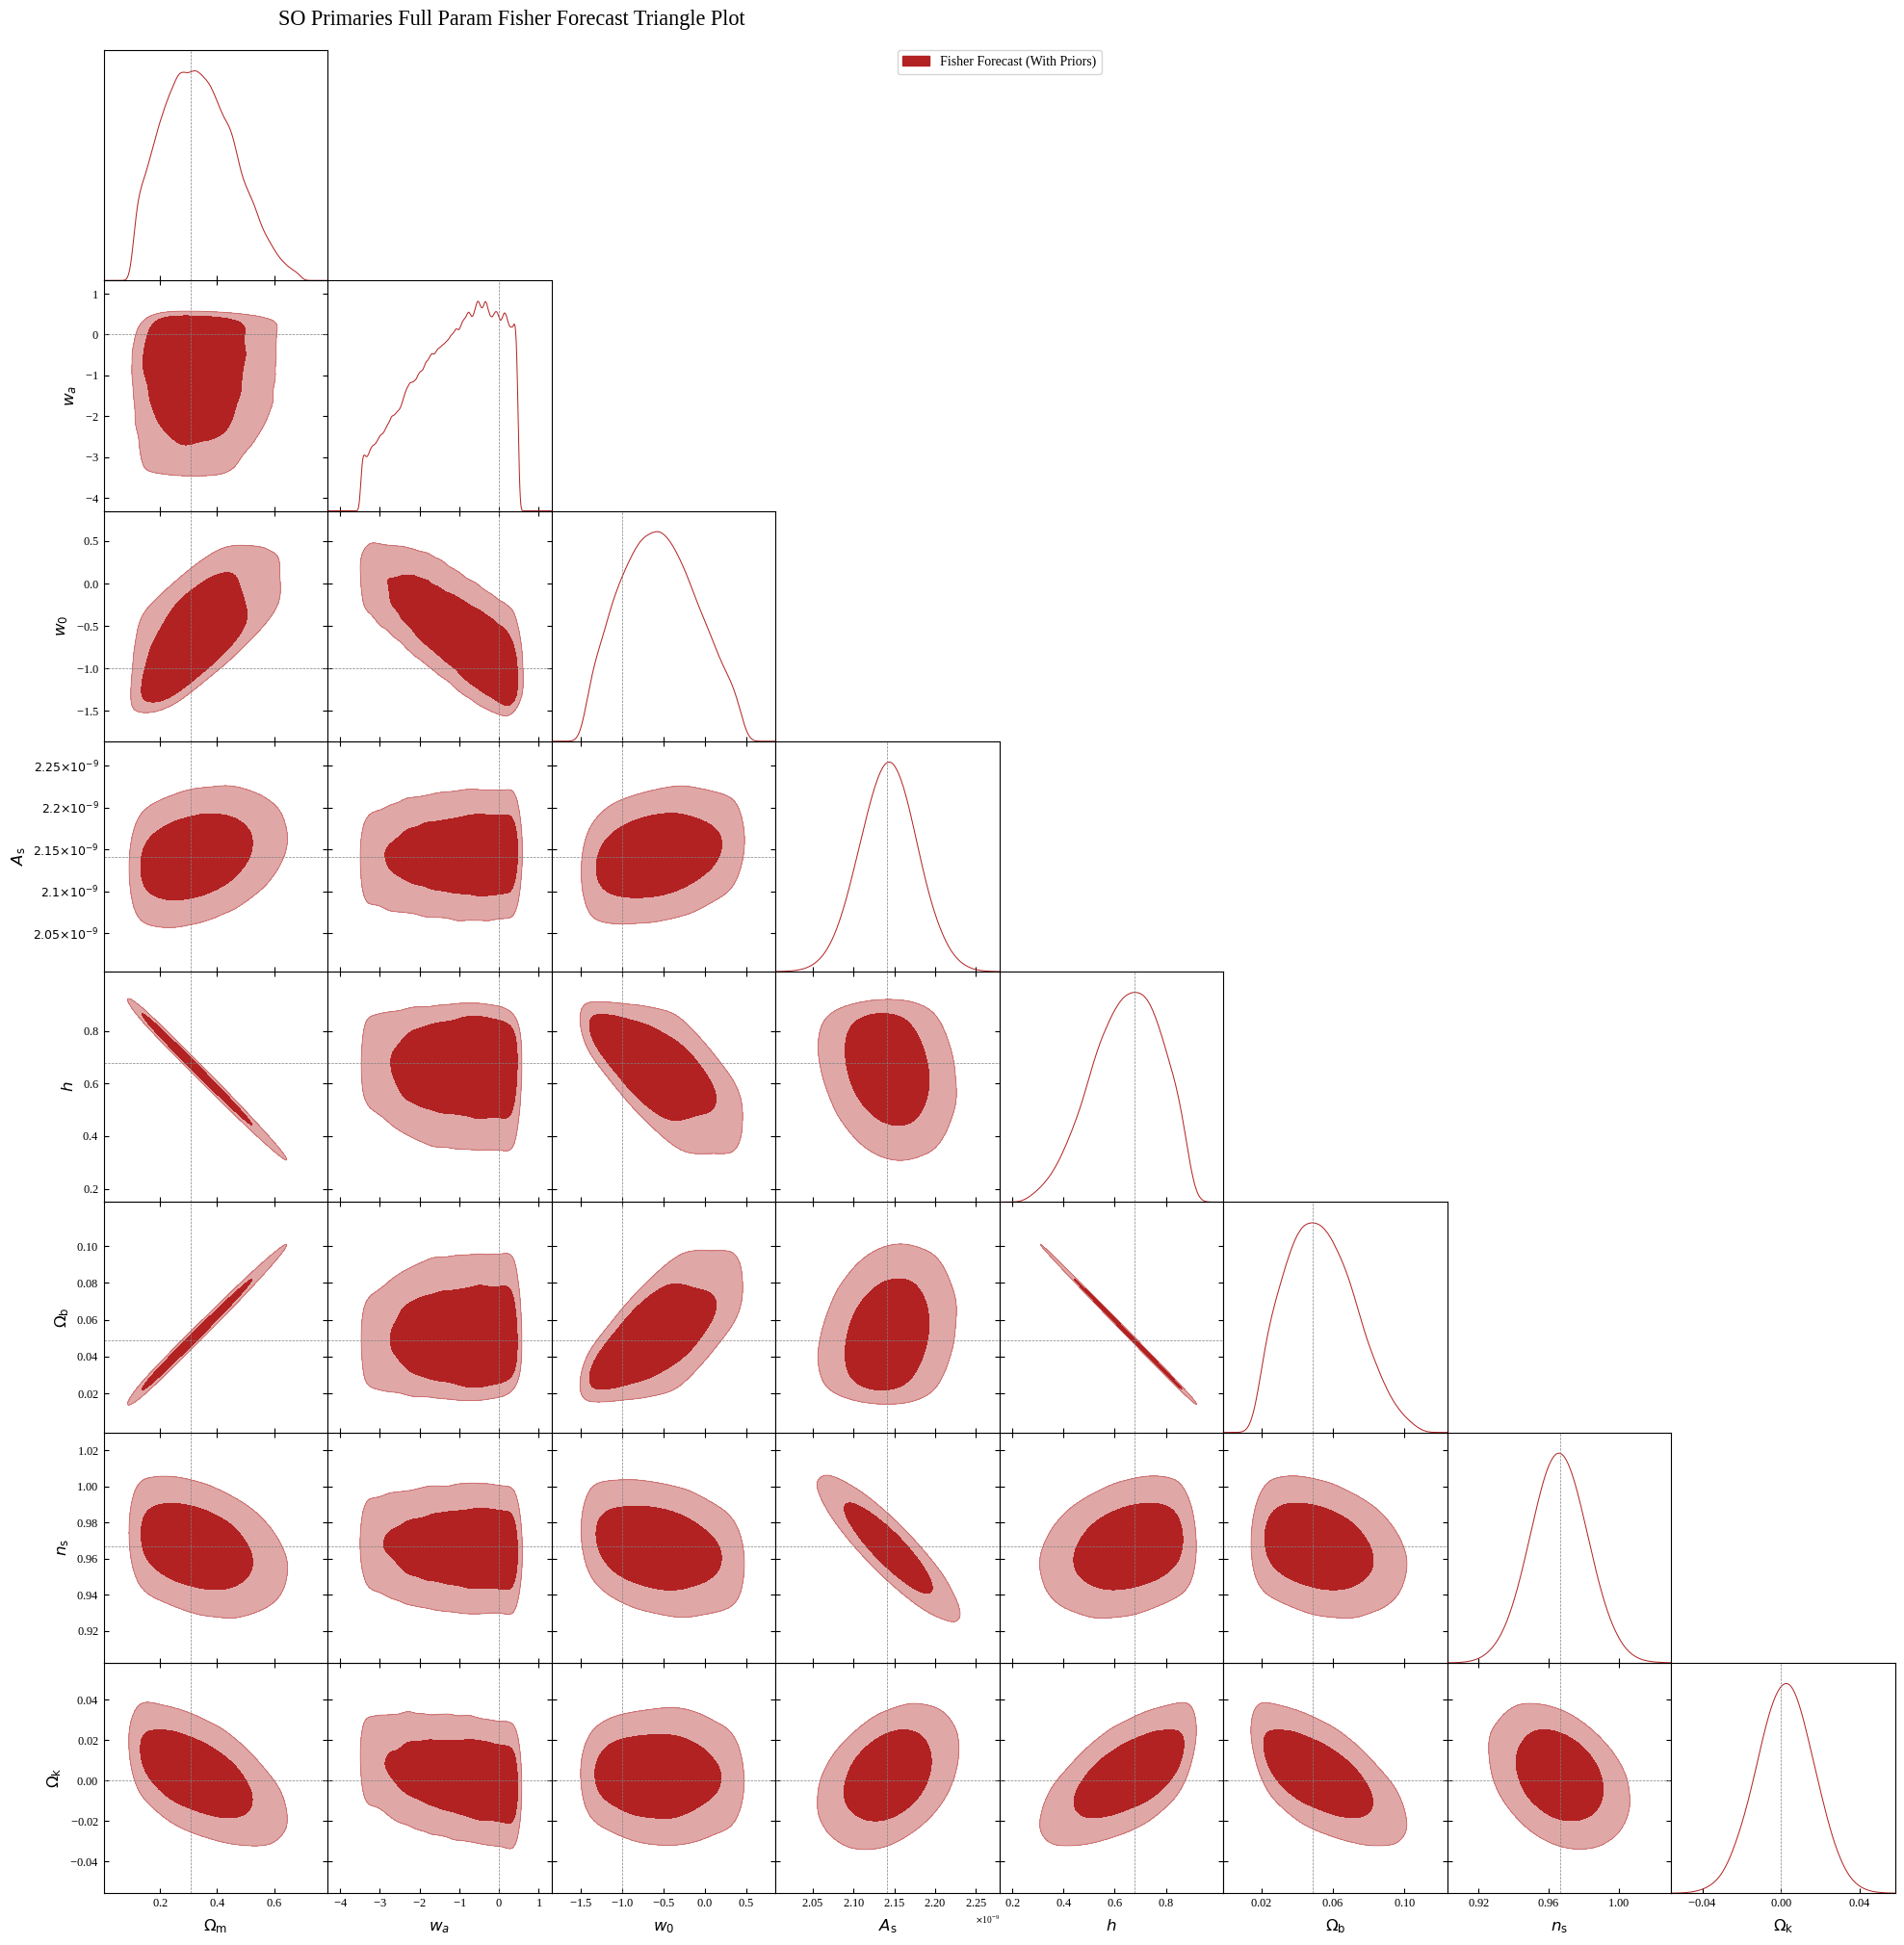

In [18]:
# Full param full spectra + primaries waw0 Fisher forecast

# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'wa': (-3.5, 0.5),
    'w0': (-1.5, 0.5),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3)
}
full_params = ['Omega_m', 'wa', 'w0', 'A_s', 'h', 'Omega_b', 'n_s', 'Omega_k']

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=full_params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primares Full Param Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True,
    num_samples = 1000000
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primaries Full Param Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    num_samples = 200000
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/so_primares_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.28}_{-0.29}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0013$ | $\Omega_m = 0.3075^{+0.0025}_{-0.0025}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0013$ | $\Omega_m = 0.3075 \pm 0.0026$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0018$ | $h = 0.6774^{+0.0035}_{-0.0035}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0018$ | $h = 0.6774 \pm 0.0036$ |
| --- | --- | --- | --- |

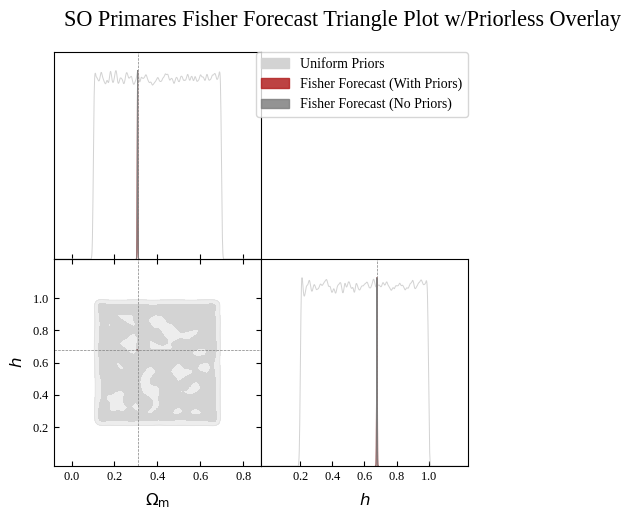

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot.pdf


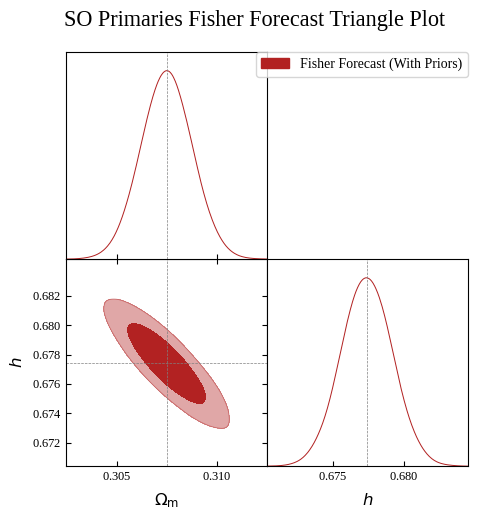

In [19]:
# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'h': (0.2, 1.0)
}
full_params = ['Omega_m', 'h']

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=full_params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primares Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True,
    num_samples = 200000
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    num_samples = 200000
)

plt.show()

Plot successfully saved to: plots/Fisher Forecasts/so_primares_fisher_forecast_triangle_plot_w/priorless_overlay.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Uniform Priors | $\Omega_m = 0.40\pm 0.17$ | $\Omega_m = 0.40^{+0.29}_{-0.28}$ |
|  | Fisher Forecast (With Priors) | $\Omega_m = 0.3075\pm 0.0026$ | $\Omega_m = 0.3075^{+0.0051}_{-0.0052}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3075 \pm 0.0026$ | $\Omega_m = 0.3075 \pm 0.0053$ |
| --- | --- | --- | --- |
| **$h$** | Uniform Priors | $h = 0.60\pm 0.23$ | $h = 0.60^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (With Priors) | $h = 0.6774\pm 0.0025$ | $h = 0.6774^{+0.0049}_{-0.0049}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6774 \pm 0.0025$ | $h = 0.6774 \pm 0.0050$ |
| --- | --- | --- | --- |
| **$A_s$** | Uniform Priors | $A_s = \left(\,3.5\pm 1.1\,\right)\cdot 10^{-9}$ | $A_s = \left(\,3.5^{+1.9}_{-1.9}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (With Priors) | $A_s = \left(\,2.1410\pm 0.0091\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.141^{+0.018}_{-0.018}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = 2.14 \cdot 10^{-9} \pm 9.12 \cdot 10^{-12}$ | $A_s = 2.14 \cdot 10^{-9} \pm 1.82 \cdot 10^{-11}$ |
| --- | --- | --- | --- |

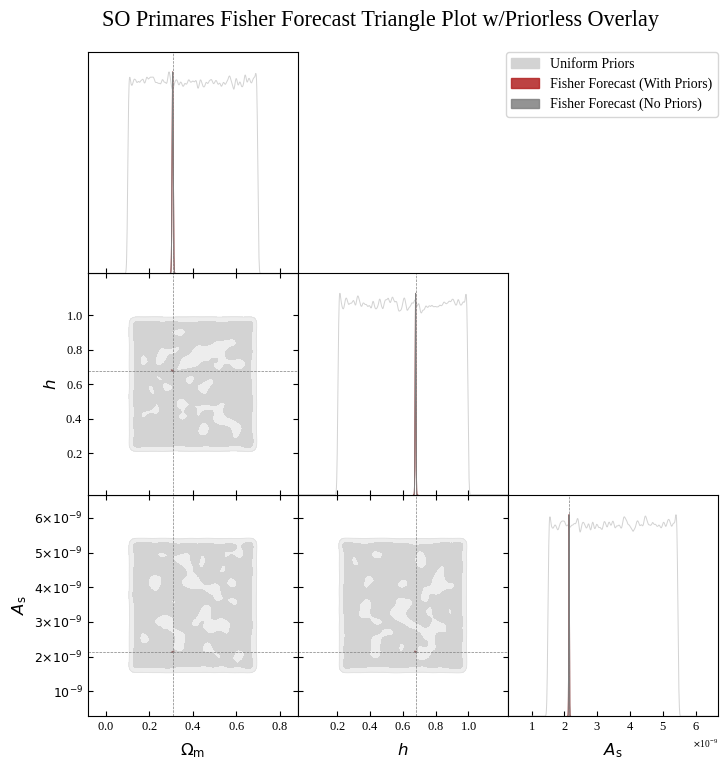

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_fisher_forecast_triangle_plot.pdf


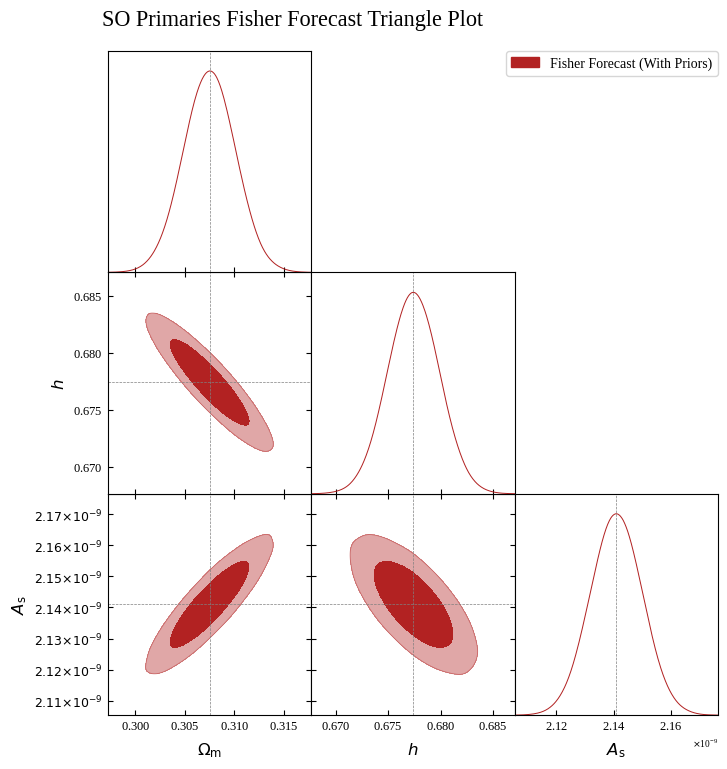

In [20]:
# cosmology
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.2589,
    Omega_b=0.04859,
    h=0.6774,
    A_s=2.141e-9,
    n_s=0.9667,
    w0=-1,
    wa=0,
    Omega_k=0,
    transfer_function='boltzmann_camb',
    extra_parameters={"camb": {"dark_energy_model": "ppf"}}
)

# define prior
uniform_prior = {
    'Omega_m': (0.1, 0.7),
    'h': (0.2, 1.0),
    'A_s': (1.48797e-9, 5.45981e-9)
}
full_params = ['Omega_m', 'h', 'A_s']

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_1_5,
    binsize=50,
    n_ell = 5000,
    f_sky = 0.44,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=None,
    shape_noise_source=None,
    desired_spectra = ['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=full_params)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primares Fisher Forecast Triangle Plot w/Priorless Overlay",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = True,
    num_samples = 200000
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    param_names=full_params,
    title="SO Primaries Fisher Forecast Triangle Plot",
    cobaya_chain_dir=None,
    sampled_params=full_params,
    uniform_priors=uniform_prior,
    overlay_priorless=False,
    save_plot = True,
    print_summary = False,
    num_samples = 200000
)

plt.show()

Loading Planck 2018 chains...


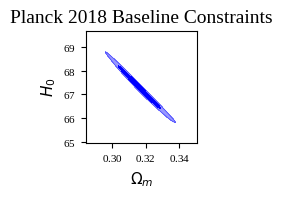

In [24]:
# Planck

# 1. Define the path to the specific chain folder you unzipped
# The unzip creates a nested 'base/plikHM_TTTEEE_lowl_lowE' directory structure
chain_dir = "./planck_chains/base/plikHM_TTTEEE_lowl_lowE"
chain_root = "base_plikHM_TTTEEE_lowl_lowE"

# 2. Load the chains using GetDist
print("Loading Planck 2018 chains...")
samples = mcsamples.loadMCSamples(f"{chain_dir}/{chain_root}", settings={'ignore_rows': 0.3})

# 3. Initialize the triangle plot
g = plots.get_subplot_plotter()

# 4. Plot a 2D contour of Omega_m vs. H0 (or any parameters in the .paramnames file)
# Note: Planck uses 'omegam' and 'H0' as parameter names
g.plot_2d(samples, 'omegam', 'H0', filled=True, colors=['blue'])

# Add title and adjust
plt.title("Planck 2018 Baseline Constraints", fontsize=14)
plt.show()

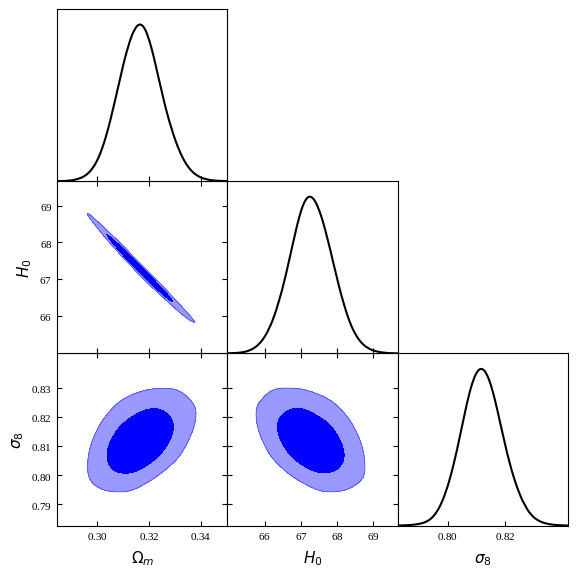

In [25]:
# 1. Initialize the subplot plotter for a triangle layout
g = plots.get_subplot_plotter()

# 2. Generate the full triangle contour plot
# Pass your samples and a list of the parameters you want to see
g.triangle_plot(
    samples, 
    ['omegam', 'H0', 'sigma8'], 
    filled=True, 
    colors=['blue'],
    line_args={'lw': 1.5}
)

# Show the full grid
plt.show()